## Workbook containing all figures produced for chapter 1 

**Table 3:** reporting of streamflow performance (NSE and KGE broken down by glaciation)

In [1]:
import numpy as np
import pandas as pd
from src.config import PROCESSED_DATA_DIR, OUTPUT_DATA_DIR, TEST_START_YEAR, TEST_END_YEAR

ENSEMBLE_MEMBERS = 10
model_list = ['topographic_lstm']

# define the evaluation metrics (NSE, KGE, and PBIAS), robust to missing values (NaNs)
def nse(obs, sim):
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    if not np.any(mask): return np.nan
    obs_masked = obs[mask]
    sim_masked = sim[mask]
    denom = np.sum((obs_masked - np.mean(obs_masked)) ** 2)
    if denom == 0: return np.nan
    return 1 - np.sum((obs_masked - sim_masked) ** 2) / denom

def kge(obs, sim):
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    if not np.any(mask) or len(obs_masked := obs[mask]) < 2: return np.nan
    sim_masked = sim[mask]
    r = np.corrcoef(obs_masked, sim_masked)[0, 1]
    std_obs = np.std(obs_masked)
    mean_obs = np.mean(obs_masked)
    if std_obs == 0 or mean_obs == 0: return np.nan
    alpha = np.std(sim_masked) / std_obs
    beta = np.mean(sim_masked) / mean_obs
    return 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

def pbias(obs, sim):
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    if not np.any(mask): return np.nan
    obs_masked = obs[mask]
    denom = np.sum(obs_masked)
    if denom == 0: return np.nan
    return 100 * np.sum(sim[mask] - obs_masked) / denom

# load the ground truth data
static_atts = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0)
streamflow = pd.read_csv(PROCESSED_DATA_DIR / "combined_streamflow.csv", index_col=0)

# Convert the ground truth streamflow data to units of mm/day
streamflow.index = pd.to_datetime(streamflow.index)
test_years_mask = (streamflow.index.year >= TEST_START_YEAR) & (streamflow.index.year <= TEST_END_YEAR)
streamflow_test = streamflow.loc[test_years_mask]

# Align the static attributes order exactly with the streamflow columns
common_columns = streamflow_test.columns.intersection(static_atts.index)
streamflow_test = streamflow_test[common_columns]
areas = static_atts.loc[common_columns, 'basin_area_km2']

# Vectorized operation across all 290 columns at once
# (m3/s) / (km2 * 1e6) * 86400 s/day * 1000 mm/m -> mm/day
conversion_factor = 86400 * 1e3 / (areas * 1e6)
streamflow_mm = streamflow_test.multiply(conversion_factor, axis=1)

# Identify glaciated stations
glacier_col = [c for c in static_atts.columns if 'glacier_pct' in c.lower()][0]
glaciated_stations = static_atts[static_atts[glacier_col] > 0].index.intersection(streamflow_mm.columns)
all_stations = streamflow_mm.columns

# Container for final report records
summary_records = []

for model in model_list:
    # Storage arrays for metrics per member per station
    # Shape: (Ensemble_Members, Stations)
    member_kge_all = np.zeros((ENSEMBLE_MEMBERS, len(all_stations)))
    member_nse_all = np.zeros((ENSEMBLE_MEMBERS, len(all_stations)))
    member_pbias_all = np.zeros((ENSEMBLE_MEMBERS, len(all_stations)))
    
    # Track ensemble mean time-series prediction per station
    ens_mean_preds = pd.DataFrame(0.0, index=streamflow_mm.index, columns=all_stations)
    
    # 1. First Pass: Load all member predictions, calculate individual metrics, and build ensemble mean
    for i in range(ENSEMBLE_MEMBERS):
        file_fact = OUTPUT_DATA_DIR / model / f"{model}_preds_member_{i}.csv"
        # Assuming predictions columns match station IDs and rows match the date index
        preds = pd.read_csv(file_fact, index_col=0)
        preds.index = pd.to_datetime(preds.index)
        preds = preds.loc[streamflow_mm.index, all_stations] # Align perfectly
        
        ens_mean_preds += preds / ENSEMBLE_MEMBERS
        
        for s_idx, station in enumerate(all_stations):
            obs_series = streamflow_mm[station].values
            sim_series = preds[station].values
            member_kge_all[i, s_idx] = kge(obs_series, sim_series)
            member_nse_all[i, s_idx] = nse(obs_series, sim_series)
            member_pbias_all[i, s_idx] = pbias(obs_series, sim_series)

    # 2. Compute metrics for the actual Ensemble Mean time series
    ens_mean_kge_all = np.array([kge(streamflow_mm[st].values, ens_mean_preds[st].values) for st in all_stations])
    ens_mean_nse_all = np.array([nse(streamflow_mm[st].values, ens_mean_preds[st].values) for st in all_stations])
    ens_mean_pbias_all = np.array([pbias(streamflow_mm[st].values, ens_mean_preds[st].values) for st in all_stations])

    # 3. Aggregate metrics over spatial subsets (All vs. Glaciated)
    for subset_name, subset_stations in [("All basins", all_stations), ("Glacierized basins", glaciated_stations)]:
        # Get positional indices of subset stations relative to the 'all_stations' list
        sub_indices = [all_stations.get_loc(st) for st in subset_stations]
        
        # Individual member spatial aggregations
        sub_member_kge = np.nanmedian(member_kge_all[:, sub_indices], axis=1)
        sub_member_nse = np.nanmedian(member_nse_all[:, sub_indices], axis=1)
        sub_member_pbias = np.nanmedian(member_pbias_all[:, sub_indices], axis=1)
        
        sub_member_kge_gt07 = np.sum(member_kge_all[:, sub_indices] > 0.7, axis=1)
        sub_member_kge_lt0 = np.sum(member_kge_all[:, sub_indices] < 0.0, axis=1)

        sub_member_nse_lt0 = np.sum(member_nse_all[:, sub_indices] < 0.0, axis=1)
        
        # Ensemble mean spatial aggregations
        ens_mean_kge_med = np.nanmedian(ens_mean_kge_all[sub_indices])
        ens_mean_nse_med = np.nanmedian(ens_mean_nse_all[sub_indices])
        ens_mean_pbias_med = np.nanmedian(ens_mean_pbias_all[sub_indices])
        ens_mean_kge_gt07 = np.sum(ens_mean_kge_all[sub_indices] > 0.7)
        ens_mean_kge_lt0 = np.sum(ens_mean_kge_all[sub_indices] < 0.0)
        ens_mean_nse_lt0 = np.sum(ens_mean_nse_all[sub_indices] < 0.0)
        # Format strings as: Single Member Mean ± Std [Ensemble Mean Prediction value]
        def format_stat(member_arr, mean_val, is_int=False):
            fmt = "{:.0f}" if is_int else "{:.2f}"
            return f"{fmt.format(np.mean(member_arr))} ± {fmt.format(np.std(member_arr))} [{fmt.format(mean_val)}]"

        summary_records.append({
            "Model": model,
            "Subset": subset_name,
            "Median KGE": format_stat(sub_member_kge, ens_mean_kge_med),
            "Median NSE": format_stat(sub_member_nse, ens_mean_nse_med),
            "Median PBIAS (%)": format_stat(sub_member_pbias, ens_mean_pbias_med, is_int=False),
            "Stations KGE > 0.7": format_stat(sub_member_kge_gt07, ens_mean_kge_gt07, is_int=True),
            "Stations KGE < 0.0": format_stat(sub_member_kge_lt0, ens_mean_kge_lt0, is_int=True),
            "Stations NSE < 0.0": format_stat(sub_member_nse_lt0, ens_mean_nse_lt0, is_int=True)
        })

# 4. Generate beautiful multi-index layout for clean terminal printing
df_res = pd.DataFrame(summary_records).set_index(["Subset", "Model"])

print("\n" + "="*95)
print("   STREAMFLOW MODEL BENCHMARK TEST SUMMARY")
print("   Format: Single Member Mean ± SD [Ensemble Mean Prediction Metric]")
print("="*95)
with pd.option_context('display.max_columns', None, 'display.width', 1000, 'display.colheader_justify', 'center'):
    print(df_res)
print("="*95 + "\n")


   STREAMFLOW MODEL BENCHMARK TEST SUMMARY
   Format: Single Member Mean ± SD [Ensemble Mean Prediction Metric]
                                         Median KGE          Median NSE        Median PBIAS (%)   Stations KGE > 0.7 Stations KGE < 0.0 Stations NSE < 0.0
Subset             Model                                                                                                                                  
All basins         topographic_lstm  0.70 ± 0.02 [0.71]  0.72 ± 0.01 [0.75]  -4.65 ± 1.86 [-4.98]    134 ± 7 [135]       10 ± 1 [9]          7 ± 2 [6]    
Glacierized basins topographic_lstm  0.89 ± 0.02 [0.91]  0.90 ± 0.00 [0.91]   -0.21 ± 1.57 [0.20]      83 ± 2 [83]        0 ± 0 [0]          0 ± 0 [0]    



Define standard inputs to be used in the figures

In [11]:
# general variables and imports
import pandas as pd
import numpy as np
from pathlib import Path
from src.config import PROCESSED_DATA_DIR, OUTPUT_DATA_DIR, OUTPUT_GLACIER_VOL_FILES

ENSEMBLE_MEMBERS = 10

# load observed streaflow and static attributes
df_obs = pd.read_csv(PROCESSED_DATA_DIR / "combined_streamflow.csv", index_col='Date', parse_dates=True)
df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0) 

# Convert streamflow to mm/day for KGE calculation
for stat in df_obs.columns:
    if stat in df_attr.index:
        area_km2 = df_attr.loc[stat, 'basin_area_km2']
        df_obs[stat] = df_obs[stat] * (86.4 / area_km2)

# load best model predictions and compute ensemble mean
best_model = 'topographic_lstm'
df_preds = []
df_cf_preds = []
for i in range(ENSEMBLE_MEMBERS):
    file_fact = OUTPUT_DATA_DIR / best_model / f"{best_model}_preds_member_{i}.csv"
    file_cf = OUTPUT_DATA_DIR / best_model / f"{best_model}_preds_noglacier_member_{i}.csv"
    df_pred = pd.read_csv(file_fact, index_col=0)
    df_cf_pred = pd.read_csv(file_cf, index_col=0)
    df_pred.index = pd.to_datetime(df_pred.index)
    df_cf_pred.index = pd.to_datetime(df_cf_pred.index)
    df_preds.append(df_pred)
    df_cf_preds.append(df_cf_pred)

# Calculate Ensemble Means
df_pred_mean = pd.concat(df_preds).groupby(level=0).mean()
df_cf_pred_mean = pd.concat(df_cf_preds).groupby(level=0).mean()

# Calculate Ensemble Standard Deviations
df_pred_std = pd.concat(df_preds).groupby(level=0).std()
df_cf_pred_std = pd.concat(df_cf_preds).groupby(level=0).std()

# Calculate Uncertainty Ratio (sigma_cf / sigma_f)
# Add a small epsilon to avoid division by zero
epsilon = 1e-6
df_uncertainty_ratio = df_cf_pred_std / (df_pred_std + epsilon)

# load the mass balance modeled meltwater contribution for each station
df_mbs = []
for i in range(len(OUTPUT_GLACIER_VOL_FILES)):
    df_mbs.append(pd.read_csv(OUTPUT_GLACIER_VOL_FILES[i], index_col=0, parse_dates=True))
df_mb = pd.concat(df_mbs).groupby(level=0).mean()
df_mb_range = pd.concat(df_mbs).groupby(level=0).agg(['min', 'max'])

# create a list of stations that are glaciated and have valid predictions
glaciated_stations = df_attr[df_attr['glacier_pct'] > 0].index.intersection(df_mb.columns)
print(f"Total stations with predictions: {len(df_pred_mean.columns)}")
print(f"Glaciated stations with predictions: {len(glaciated_stations)}")

# define delta-Q and mass balance predictions for glaciated stations
dq_pred = df_pred_mean[glaciated_stations] - df_cf_pred_mean[glaciated_stations]  # Predicted glacier contribution (mm/day)
mb_pred = df_mb[glaciated_stations]  # Modeled glacier contribution (mm/day)
mb_pred_range = df_mb_range[glaciated_stations]  # Range of modeled glacier contribution (MCM)

# generate ensemble range of dq
dq_preds = []
for i in range(ENSEMBLE_MEMBERS):
    dq_preds.append(df_preds[i][glaciated_stations] - df_cf_preds[i][glaciated_stations])
dq_pred_range = pd.concat(dq_preds).groupby(level=0).agg(['min', 'max'])

# convert to units of MCM
dq_pred_mcm = dq_pred.multiply(df_attr.loc[glaciated_stations, 'basin_area_km2'], axis=1) / 1e3
mb_pred_mcm = mb_pred.multiply(df_attr.loc[glaciated_stations, 'basin_area_km2'], axis=1) / 1e3

# convert to units of mm over glacier area
dq_pred_mm_glacier = dq_pred.divide((df_attr.loc[glaciated_stations, 'glacier_pct'] / 100), axis=1)
mb_pred_mm_glacier = mb_pred.divide((df_attr.loc[glaciated_stations, 'glacier_pct'] / 100), axis=1)

# perform imputation on the ground truth streamflow data
df_obs_imputed = df_obs.interpolate(method='linear', limit=7)
df_obs_imputed = df_obs_imputed.fillna(df_obs_imputed.groupby(df_obs_imputed.index.dayofyear).transform('mean'))
df_obs_imputed = df_obs_imputed.fillna(df_obs_imputed.min())
q_obs_filtered = df_obs_imputed[glaciated_stations]

# Define the figure directory
fig_dir = Path('../figures')
# Create the directory if it doesn't exist
fig_dir.mkdir(parents=True, exist_ok=True)

def kge(obs, sim):
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    if not np.any(mask) or len(obs_masked := obs[mask]) < 2: return np.nan
    sim_masked = sim[mask]
    r = np.corrcoef(obs_masked, sim_masked)[0, 1]
    std_obs = np.std(obs_masked)
    mean_obs = np.mean(obs_masked)
    if std_obs == 0 or mean_obs == 0: return np.nan
    alpha = np.std(sim_masked) / std_obs
    beta = np.mean(sim_masked) / mean_obs
    return 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

Total stations with predictions: 269
Glaciated stations with predictions: 87


**Figure 1:** Sketch of counterfactual hypothesis

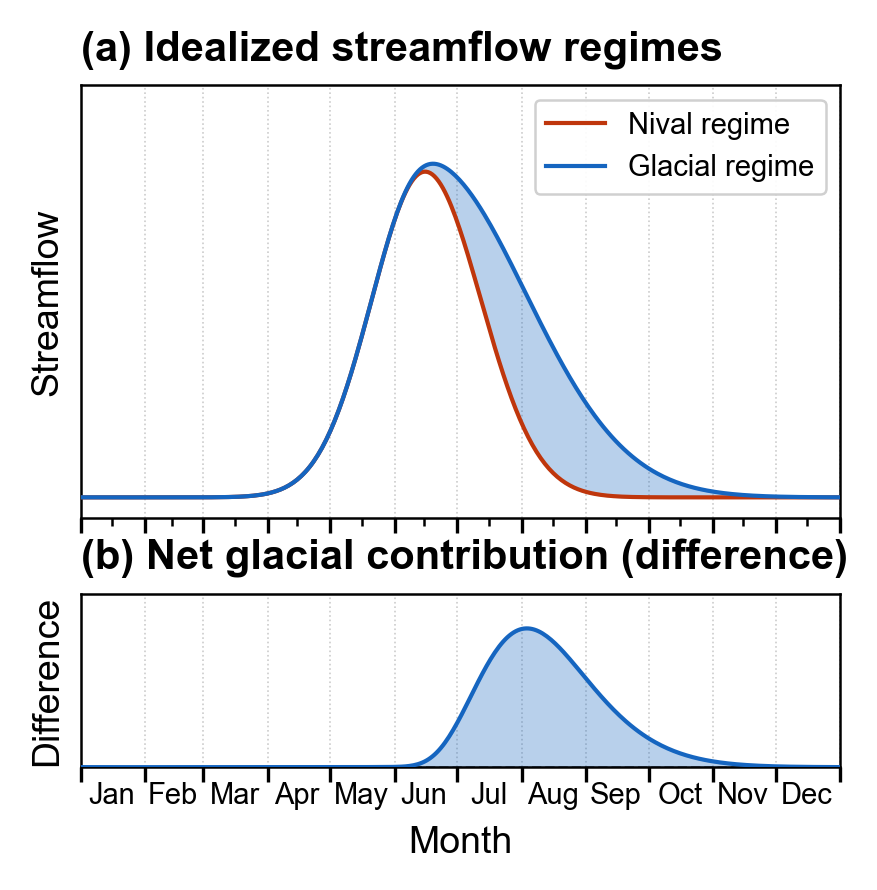

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.ndimage import gaussian_filter1d
import matplotlib.patches as mpatches
import warnings

warnings.filterwarnings('ignore')

# ─── 1. GLOBAL FORMATTING SETUP ───────────────────────────────────────────────
cm = 1 / 2.54
SINGLE_COL = 8.3 * cm
DOUBLE_COL = 12.0 * cm

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 7,
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'legend.title_fontsize': 8,
    'axes.linewidth': 0.6,
    'lines.linewidth': 1.0,      # Keeps plot lines strong
    'lines.markersize': 4,
    'patch.linewidth': 0.6,
    'savefig.format': 'pdf',
    'savefig.bbox': 'tight',
    'figure.dpi': 300
})

# ─── 2. SIMULATION DATA ───────────────────────────────────────────────────────
days = 365
doy  = np.arange(1, 366, dtype=float)

T = -8 + 13 * np.sin(np.pi * (doy - 15) / 180)   
T = gaussian_filter1d(np.tile(T,3), sigma=12)[days:2*days]

rng = np.random.default_rng(99)
P = 2.8 + 0.5*np.sin(2*np.pi*(doy-280)/365)
P += 0.3 * rng.standard_normal(days)
P = gaussian_filter1d(np.clip(np.tile(P,3), 0.3, 7), sigma=12)[days:2*days]

def RF(T, Tlo=0, Thi=2):
    return np.clip((T-Tlo)/(Thi-Tlo), 0, 1)

rain_frac = RF(T)
Psnow = (1-rain_frac)*P
Prain = rain_frac*P

DDF_snow = 4.0   
DDF_ice  = 8.5   
Tpos = np.where(T>0, T, 0.0)

def simulate(nyears=10, with_glacier=False, Toffset=0.0):
    Tloc = T - Toffset
    Tpos_l = np.where(Tloc > 0, Tloc, 0.0)
    rf_l   = RF(Tloc)
    Ps_l   = (1-rf_l)*P
    Pr_l   = rf_l*P

    DDF_s  = DDF_snow
    DDF_ic = DDF_ice
    k_gw   = 0.016 if not with_glacier else 0.012
    et_fac = 0.55  if not with_glacier else 0.35

    all_Q = []
    SWE = 300.0
    GW  = 20.0
    SWE_glac = 800.0   

    for yr in range(nyears):
        if with_glacier:
            SWE_glac = 800.0   
        Q_yr = np.zeros(days)

        for i in range(days):
            SWE += Ps_l[i]
            m_snow = min(DDF_s * Tpos_l[i], SWE)
            SWE = max(SWE - m_snow, 0)

            ice_melt = 0.0
            if with_glacier:
                SWE_glac += Ps_l[i] * 0.5   
                m_gsnow = min(DDF_s * Tpos_l[i], SWE_glac)
                SWE_glac = max(SWE_glac - m_gsnow, 0)
                if SWE_glac <= 5.0 and Tpos_l[i] > 0:
                    ice_melt = DDF_ic * Tpos_l[i]
            else:
                m_gsnow = 0.0

            avail = Pr_l[i] + m_snow + m_gsnow + ice_melt
            et = 0.0 if Tloc[i] < 3 else min(et_fac * Tpos_l[i]**0.8, avail*0.5)
            avail = max(avail - et, 0)

            GW  += avail * 0.28
            bf   = k_gw * GW
            GW   = max(GW - bf, 0)
            Q_yr[i] = avail * 0.72 + bf

        all_Q.append(Q_yr)

    return np.mean(all_Q[4:], axis=0)

Qn_raw = simulate(nyears=10, with_glacier=False, Toffset=0.0)
Qg_raw = simulate(nyears=10, with_glacier=True,  Toffset=1.0)

def smooth(Q, sig=20):
    Q3 = np.tile(Q,3)
    return gaussian_filter1d(Q3, sigma=sig)[days:2*days]

Qn_s = smooth(Qn_raw, sig=18)
Qg_s = smooth(Qg_raw, sig=18)

peak_day = 165          
rise_days = 60          
fall_nival  = 65        
fall_glacial = 120      

def asymm_gaussian(doy, peak, rise_sigma, fall_sigma):
    d = doy - peak
    sigma = np.where(d < 0, rise_sigma, fall_sigma)
    return np.exp(-0.5 * (d/sigma)**2)

nival_freshet   = asymm_gaussian(doy, peak_day, rise_days/2.5, fall_nival/2.5)
glacial_freshet = asymm_gaussian(doy, peak_day, rise_days/2.5, fall_glacial/2.5)

base  = 0.06
amp_n = 0.94    
amp_g = 0.94    

Qn_ideal = base + amp_n * nival_freshet
Qg_ideal = base + amp_g * glacial_freshet

Qn_ideal = smooth(Qn_ideal, sig=8)
Qg_ideal = smooth(Qg_ideal, sig=8)

def rescale(Q, base_val=base, peak_val=1.0):
    mn, mx = Q.min(), Q.max()
    return base_val + (peak_val - base_val) * (Q - mn)/(mx - mn)

Qn_f = rescale(Qn_ideal, peak_val=1.0)

optimal_peak = 1.0
Qg_f = rescale(Qg_ideal, peak_val=optimal_peak)

while np.min(Qg_f - Qn_f) < -0.0001:
    optimal_peak += 0.001
    Qg_f = rescale(Qg_ideal, peak_val=optimal_peak)

months   = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
m_starts = [0,31,59,90,120,151,181,212,243,273,304,334]
m_ends   = [30,58,89,119,150,180,211,242,272,303,333,364]

# ─── 3. REFACTORED PLOTTING BLOCK ─────────────────────────────────────────────

# Sets ax2's height to be proportional to its y-limits relative to ax1
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(SINGLE_COL, 7.5 * cm), sharex=True, 
                               gridspec_kw={'hspace': 0.25, 'height_ratios': [1.25, 0.5]})

c_niv = '#BF360C'   
c_gla = '#1565C0'   

# --- PANEL (a): The Idealized Regimes ---
ax1.set_title('(a) Idealized streamflow regimes', loc='left', fontweight='bold')

ax1.fill_between(doy, Qn_f, Qg_f, interpolate=True, color=c_gla, alpha=0.3, zorder=2)

ax1.plot(doy, Qn_f, color=c_niv, ls='-', label='Nival regime', zorder=4)
ax1.plot(doy, Qg_f, color=c_gla, ls='-', label='Glacial regime', zorder=5)

ax1.set_xlim(1, 365)
ax1.set_ylim(0, 1.25)
ax1.set_ylabel('Streamflow')
ax1.set_yticks([])

# Standard legend without August highlight
ax1.legend(loc='upper right', framealpha=0.92, edgecolor='#ccc')

# --- PANEL (b): The Difference Curve ---
ax2.set_title('(b) Net glacial contribution (difference)', loc='left', fontweight='bold')

Q_diff = Qg_f - Qn_f

ax2.axhline(0, color='black', ls='--', lw=0.6, alpha=0.6, zorder=1)

ax2.plot(doy, Q_diff, color=c_gla, zorder=4)
ax2.fill_between(doy, 0, Q_diff, color=c_gla, alpha=0.3, zorder=2)

# Enforce exact same scale as ax1 via the height_ratios mapping defined above
ax2.set_ylim(0, 0.5)  
ax2.set_ylabel('Difference')
ax2.set_xlabel('Month')
ax2.set_yticks([])

# --- Shared Grid Formatting ---
# Combine start days with the end of the year to form the full boundaries
bounds = m_starts + [365] 
m_mid = [(m_starts[m] + m_ends[m]) // 2 for m in range(12)]

for ax in [ax1, ax2]:
    for ms in bounds:
        # Finer background lines
        ax.axvline(ms, color='#ccc', ls=':', lw=0.4, zorder=0) 
        
# 1. Place major ticks at month boundaries (without text labels)
ax2.set_xticks(bounds)
ax2.set_xticklabels([])

# 2. Place minor ticks at month centers (with text labels, but hide the tick marks themselves)
ax2.set_xticks(m_mid, minor=True)
ax2.set_xticklabels(months, minor=True)
ax2.tick_params(axis='x', which='minor', length=0) 

plt.savefig('..//figures/fig01.pdf')
plt.show()

**Figure 2:** Methods flowchart

Created using Power Point. See Zenodo download for source.

**Figure 3:** Map of KGE performance with regional clusters

Calculating KGE values on test set...
Computing hydrographs and clustering...
Generating Voronoi spatial grid...

Median KGE by Spatial Cluster:
Eastern         (n=38 ): 0.276
Northeastern    (n=52 ): 0.623
Northwestern    (n=52 ): 0.895
Coastal         (n=12 ): 0.515
Central         (n=36 ): 0.845
Southern        (n=79 ): 0.835

Rendering final plot...


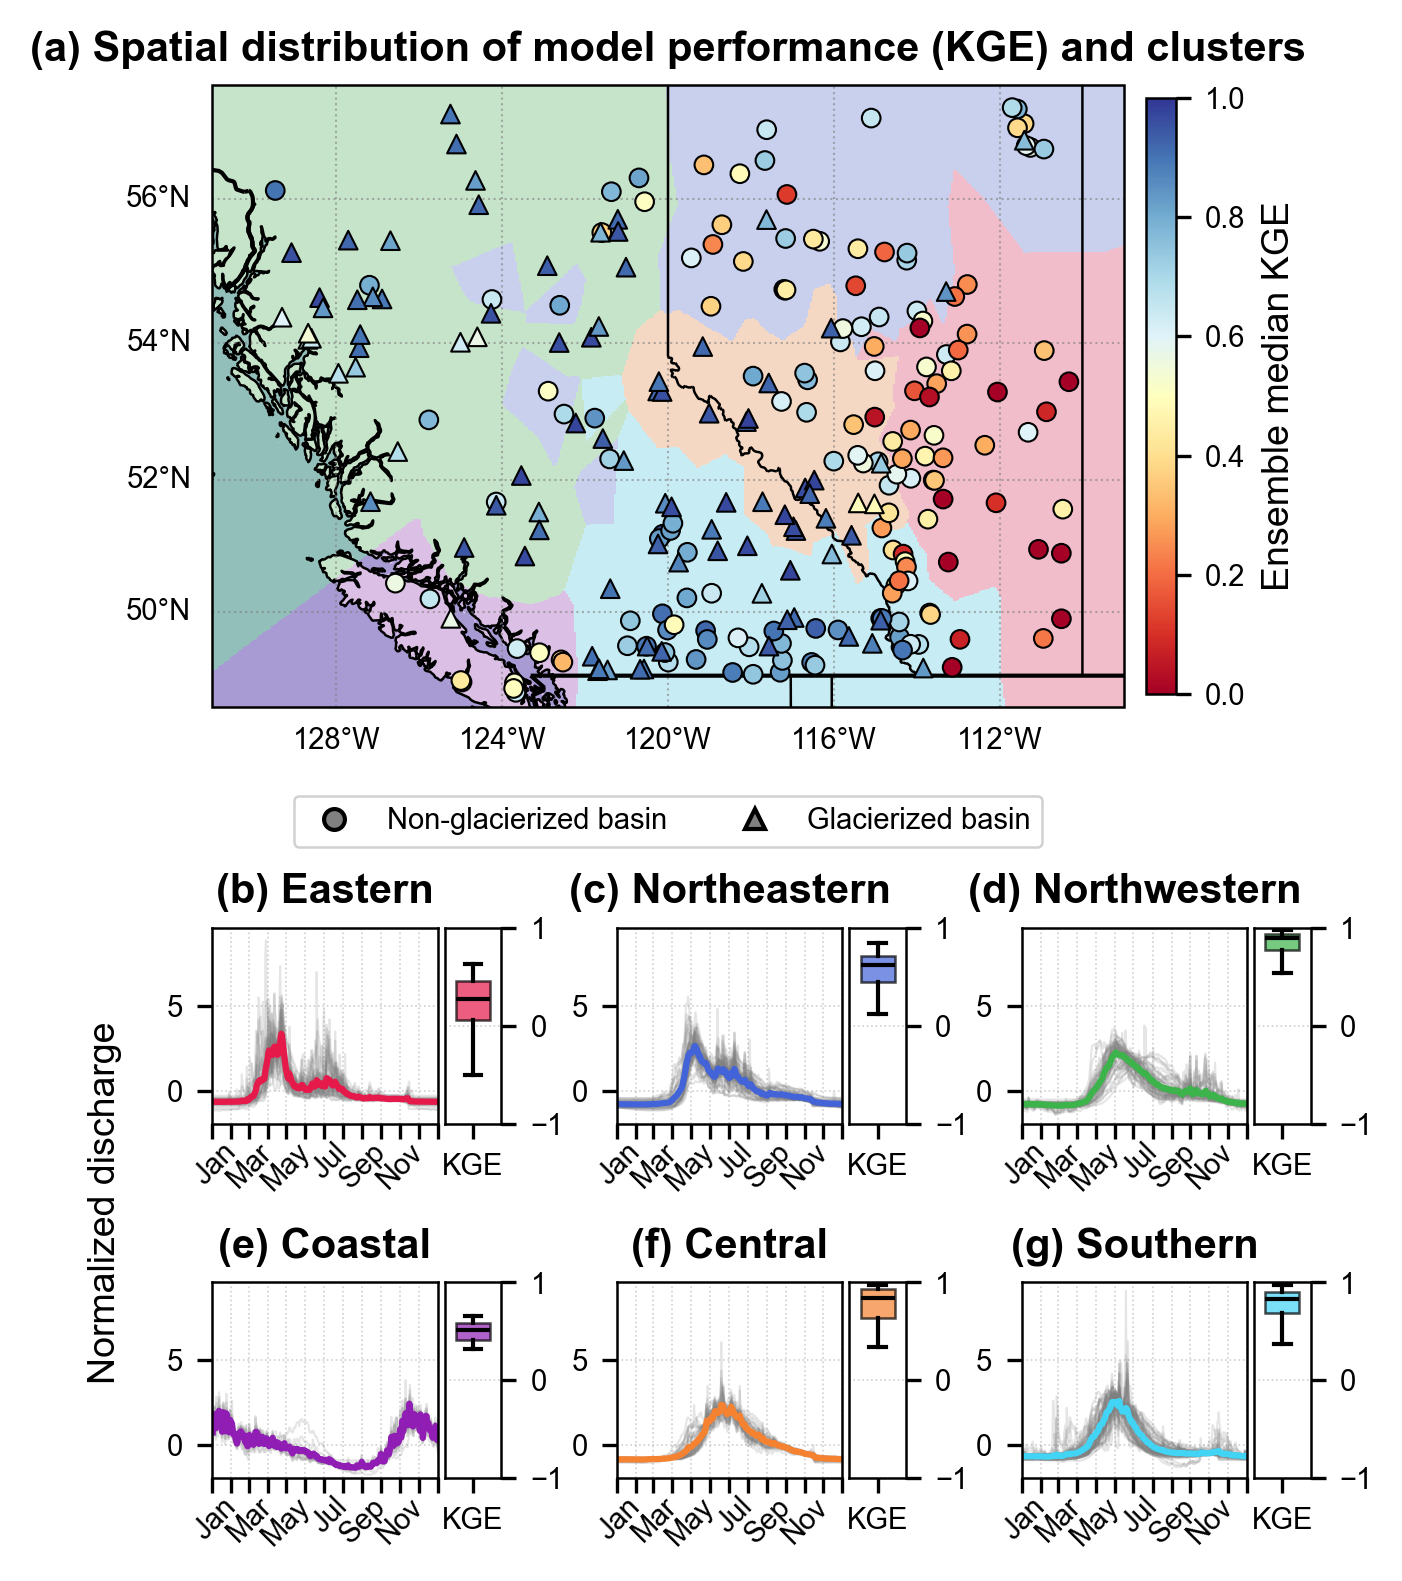

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.neighbors import KNeighborsClassifier
from matplotlib.colors import ListedColormap
import pandas as pd
import numpy as np
import warnings
from src.config import TEST_START_YEAR, TEST_END_YEAR

warnings.filterwarnings('ignore')

# =========================================================
# 1. Temporal Filtering for KGE (Test Period Only)
# =========================================================
df_obs_test = df_obs[(df_obs.index.year >= TEST_START_YEAR) & (df_obs.index.year <= TEST_END_YEAR)]
df_pred_test = df_pred[(df_pred.index.year >= TEST_START_YEAR) & (df_pred.index.year <= TEST_END_YEAR)]

# =========================================================
# 2. Imputation for Hydrographs (Using ENTIRE Dataset)
# =========================================================
df_obs_imputed = df_obs.interpolate(method='linear', limit=7)
df_obs_imputed = df_obs_imputed.fillna(df_obs_imputed.groupby(df_obs_imputed.index.dayofyear).transform('mean'))
df_obs_imputed = df_obs_imputed.fillna(df_obs_imputed.min())

# =========================================================
# 3. Calculate KGE across Ensemble Mean (No Interpolation)
# =========================================================
print("Calculating KGE values on test set...")
all_stations = df_obs.columns
station_median_kge = {}

for stat in all_stations:
    if stat in df_pred_test.columns:
        obs_vals = df_obs_test[stat].values
        sim_vals = df_pred_test[stat].values
        stat_kge = kge(obs_vals, sim_vals)
        station_median_kge[stat] = np.clip(stat_kge, -0.5, 1)

df_kge = pd.DataFrame.from_dict(station_median_kge, orient='index', columns=['KGE'])
glacier_col = [c for c in df_attr.columns if 'glac' in c.lower()][0]

# =========================================================
# 4. Clustering (Using Hydrographs + Spatial Coordinates)
# =========================================================
print("Computing hydrographs and clustering...")
avg_hydrograph = df_obs_imputed.groupby(df_obs_imputed.index.dayofyear).mean()
avg_hydrograph_norm = (avg_hydrograph - avg_hydrograph.mean()) / avg_hydrograph.std()

X_hydro = avg_hydrograph_norm.T
X_merged = X_hydro.join(df_attr[['latitude', 'longitude']], how='inner')

hydro_features = X_merged.drop(columns=['latitude', 'longitude']).values
lat_norm = (X_merged['latitude'] - X_merged['latitude'].mean()) / X_merged['latitude'].std()
lon_norm = (X_merged['longitude'] - X_merged['longitude'].mean()) / X_merged['longitude'].std()

lat_features = np.tile(lat_norm.values, (182, 1)).T
lon_features = np.tile(lon_norm.values, (182, 1)).T

X_cluster_input = np.hstack((hydro_features, lat_features, lon_features))
Z = linkage(X_cluster_input, method='ward')
cluster_labels = fcluster(Z, t=6, criterion='maxclust') - 1

df_plot = pd.DataFrame({'Cluster': cluster_labels}, index=X_merged.index)
df_plot = df_plot.join(df_attr[['latitude', 'longitude', glacier_col]], how='inner')
df_plot = df_plot.rename(columns={glacier_col: 'glacier_pct'})
df_plot = df_plot.join(df_kge, how='inner')
df_plot['glacier_pct'] = df_plot['glacier_pct'].fillna(0)

cluster_names = {0: "Eastern", 1: "Northeastern", 2: "Northwestern", 3: "Coastal", 4: "Central", 5: "Southern"}
cluster_colors = ['#e6194B', '#4363d8', '#3cb44b', '#911eb4', '#f58231', '#42d4f4']
cmap_clusters = ListedColormap(cluster_colors)

# =========================================================
# 5. Generate Voronoi Grid (KNN Approach)
# =========================================================
print("Generating Voronoi spatial grid...")
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(df_plot[['longitude', 'latitude']], df_plot['Cluster'])

xx, yy = np.meshgrid(np.linspace(-132, -108, 500), np.linspace(48.5, 57.5, 500))
Z_grid = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z_grid = Z_grid.reshape(xx.shape)

# =========================================================
# 6. Plotting - Master Layout
# =========================================================
print("\n=========================================")
print("Median KGE by Spatial Cluster:")
print("=========================================")
for cid in range(6):
    med_kge = df_plot.loc[df_plot['Cluster'] == cid, 'KGE'].median()
    count = len(df_plot.loc[df_plot['Cluster'] == cid, 'KGE'].dropna())
    print(f"{cluster_names[cid]:<15} (n={count:<3}): {med_kge:.3f}")
print("=========================================\n")

print("Rendering final plot...")

fig = plt.figure(figsize=(DOUBLE_COL, 16 * cm))
gs = fig.add_gridspec(4, 3, height_ratios=[1.5, 1.5, 1, 1], hspace=0.65, wspace=0.4)

# --- PANEL A: The Map ---
ax_map = fig.add_subplot(gs[0:2, :], projection=ccrs.Mercator())

# Widened the map extent slightly to allow it to fill out horizontally
ax_map.set_extent([-131, -109, 48.5, 57.5], crs=ccrs.PlateCarree())

res = '10m' 
ax_map.add_feature(cfeature.LAND.with_scale(res), facecolor='whitesmoke', zorder=0)
ax_map.add_feature(cfeature.OCEAN.with_scale(res), facecolor='lightsteelblue', zorder=0)
ax_map.add_feature(cfeature.COASTLINE.with_scale(res), edgecolor='black', linewidth=0.6, zorder=2)

provinces = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lines', scale=res, facecolor='none')
ax_map.add_feature(provinces, edgecolor='black', linewidth=0.6, zorder=3)
ax_map.add_feature(cfeature.BORDERS.with_scale(res), linestyle='-', edgecolor='black', linewidth=1.0, zorder=3)

### Geographic Coordinates (Graticule) ###
gl = ax_map.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), color='gray', linestyle=':', lw=0.5, alpha=0.6)
gl.top_labels = False
gl.right_labels = False
# Set custom frequency: Every 4 degrees for longitude, every 2 degrees for latitude
gl.xlocator = mticker.MultipleLocator(4)
gl.ylocator = mticker.MultipleLocator(2)

# Plot Voronoi Shading
ax_map.pcolormesh(xx, yy, Z_grid, cmap=cmap_clusters, alpha=0.25, transform=ccrs.PlateCarree(), zorder=1)

# Plot Heatmap Points (Non-glaciated)
sc_non_glac = ax_map.scatter(
    df_plot[df_plot['glacier_pct'] == 0]['longitude'], 
    df_plot[df_plot['glacier_pct'] == 0]['latitude'],
    c=df_plot[df_plot['glacier_pct'] == 0]['KGE'],
    cmap='RdYlBu', vmin=0, vmax=1,  
    s=20, marker='o', edgecolors='k', linewidths=0.5, transform=ccrs.PlateCarree(), zorder=5
)

# Plot Heatmap Points (Glaciated) 
sc_glac = ax_map.scatter(
    df_plot[df_plot['glacier_pct'] > 0]['longitude'], 
    df_plot[df_plot['glacier_pct'] > 0]['latitude'],
    c=df_plot[df_plot['glacier_pct'] > 0]['KGE'],
    cmap='RdYlBu', vmin=0, vmax=1,  
    s=20, marker='^', edgecolors='k', linewidths=0.5, transform=ccrs.PlateCarree(), zorder=6
)

cbar = plt.colorbar(sc_non_glac, ax=ax_map, orientation='vertical', pad=0.02, shrink=0.8)
cbar.set_label('Ensemble median KGE')

### Side-by-Side Legend underneath the map ###
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=5, markeredgecolor='k', label='Non-glacierized basin'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markersize=5, markeredgecolor='k', label='Glacierized basin')
]

# Lowered bbox_to_anchor slightly further to prevent overlap with new lat/lon labels
ax_map.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, framealpha=0.9)
ax_map.set_title('(a) Spatial distribution of model performance (KGE) and clusters', fontweight='bold')

# --- PANEL B-G: The Hydrographs and KGE Boxplots ---
month_bounds = [0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334, 365]
month_midpoints = [(month_bounds[m] + month_bounds[m+1]) // 2 for m in range(12)]
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Filter to every second month
bimonthly_midpoints = [month_midpoints[i] for i in range(0, 12, 2)]
bimonthly_labels = [month_labels[i] for i in range(0, 12, 2)]

global_hydro_max = avg_hydrograph_norm.max().max()
global_hydro_min = avg_hydrograph_norm.min().min()

# Common invisible axis for the central 'Normalized Discharge' label
ax_common = fig.add_subplot(gs[2:, :], frameon=False)
ax_common.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
ax_common.grid(False)

# Reduced labelpad to move label closer
ax_common.set_ylabel('Normalized discharge', labelpad=5, fontsize=9)

for cluster_id in range(6):
    row = 2 + (cluster_id // 3)
    col = cluster_id % 3
    
    inner_gs = gs[row, col].subgridspec(1, 2, width_ratios=[4, 1], wspace=0.05)
    
    ax_hydro = fig.add_subplot(inner_gs[0])
    ax_box = fig.add_subplot(inner_gs[1])
    
    panel_letter = chr(98 + cluster_id) 
    ax_hydro.set_title(f"({panel_letter}) {cluster_names[cluster_id]}", fontweight='bold')

    station_names = df_plot[df_plot['Cluster'] == cluster_id].index
    cluster_hydro_data = avg_hydrograph_norm[station_names]
    cluster_kge = df_plot.loc[station_names, 'KGE'].dropna()
    
    # -- 1. Plot Hydrograph --
    ax_hydro.plot(cluster_hydro_data.index, cluster_hydro_data.values, color='gray', alpha=0.2, linewidth=0.5)
    cluster_mean = cluster_hydro_data.mean(axis=1)
    ax_hydro.plot(cluster_mean.index, cluster_mean.values, color=cluster_colors[cluster_id], linewidth=1.5)
    
    # Set major ticks at month boundaries (without text)
    ax_hydro.set_xticks(month_bounds)
    ax_hydro.set_xticklabels([])
    
    # Set minor ticks at bimonthly centers (with text, rotated)
    ax_hydro.set_xticks(bimonthly_midpoints, minor=True)
    ax_hydro.set_xticklabels(bimonthly_labels, minor=True, rotation=45, ha='right', rotation_mode="anchor")
    ax_hydro.tick_params(axis='x', which='minor', length=0)
    
    ax_hydro.set_xlim(0, 365)
    ax_hydro.set_ylim(global_hydro_min - 0.2, global_hydro_max + 0.5)
    ax_hydro.grid(True, linestyle=':', lw=0.4, alpha=0.6)
        
    # -- 2. Plot Boxplot --
    box = ax_box.boxplot(cluster_kge, showfliers=False, widths=0.6, patch_artist=True)
    
    for patch in box['boxes']:
        patch.set_facecolor(cluster_colors[cluster_id])
        patch.set_alpha(0.7)
        patch.set_linewidth(0.6)
    for median in box['medians']:
        median.set(color='black', linewidth=1.0)
        
    # Scale boxplots downwards to -1
    ax_box.set_ylim(-1, 1)
    ax_box.set_xticks([1])
    ax_box.set_xticklabels(['KGE'])
    
    ax_box.yaxis.tick_right()
    ax_box.grid(True, axis='y', linestyle=':', lw=0.4, alpha=0.6)

plt.savefig('..//figures/fig03.png')
plt.show()

**Figure 4:** SOM cluster patterns

Extracting data and setting up specific yield...
Building datasets (Climatology Mode: False)...
Running SOM clustering (2x2 grid) on N=3741 samples...
Generating topological cluster plots...

--- Cluster Assignments ---
Enhanced Glacier Response: 19.7%
Compensating Spring Response: 7.4%
Late-Summer Glacier Response: 60.9%
Non-physical Response: 12.0%


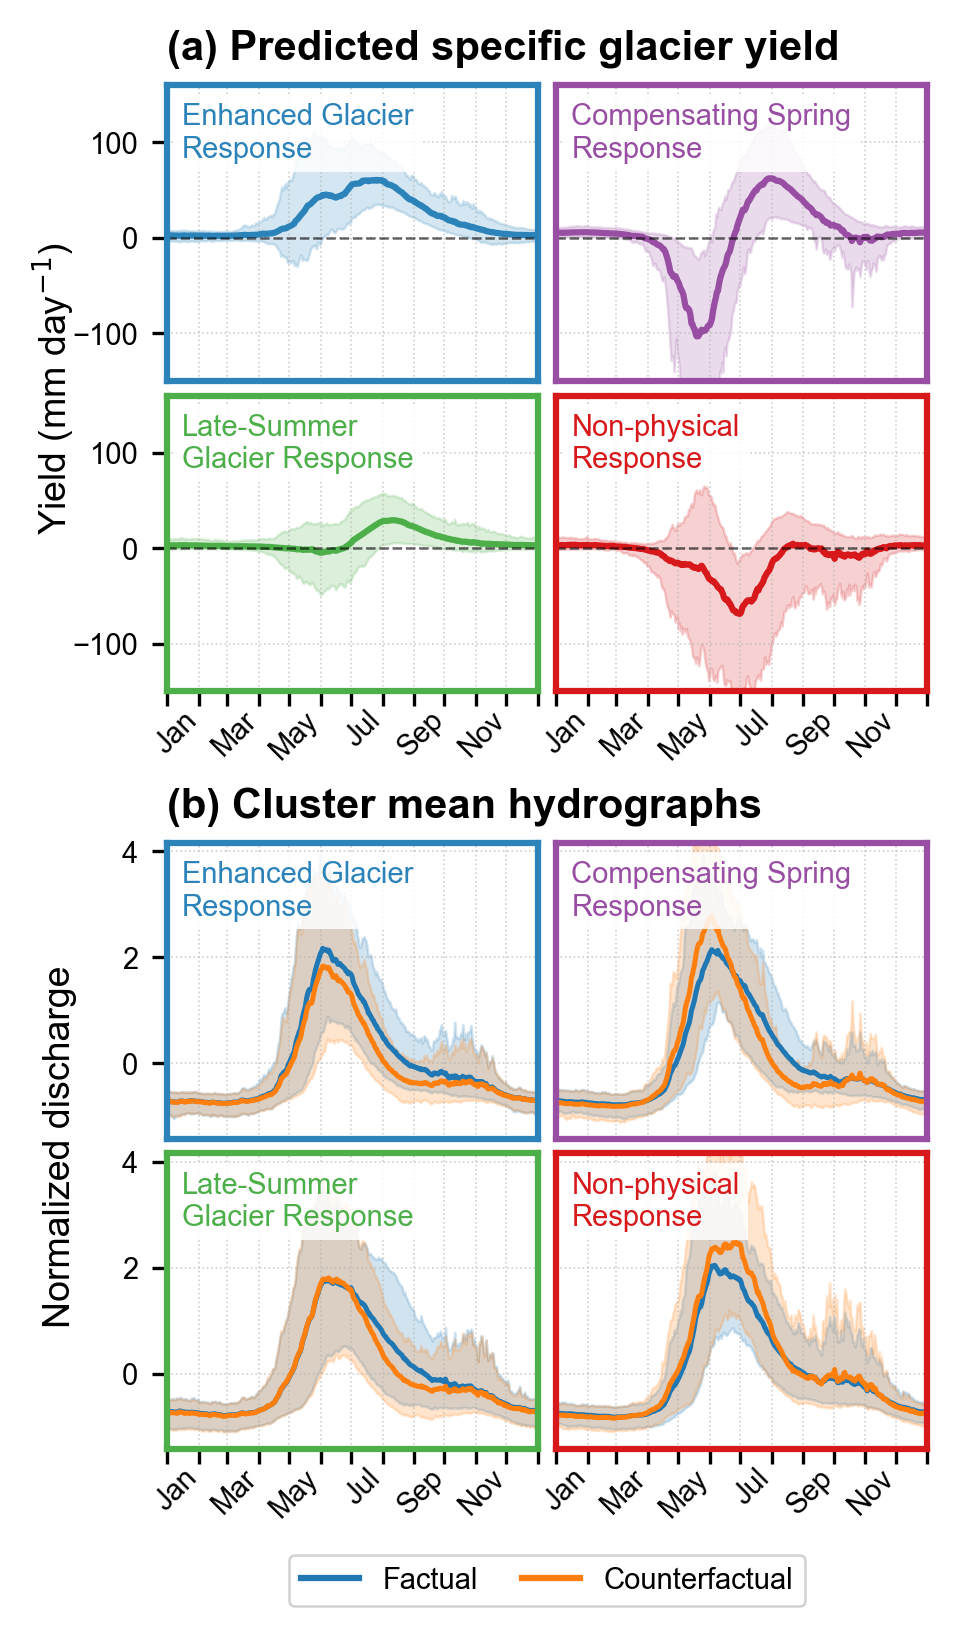

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from minisom import MiniSom
import warnings
from matplotlib.lines import Line2D

warnings.filterwarnings('ignore')

# =========================================================
# 1. USER INPUTS & TOGGLES
# =========================================================
CLUSTER_CLIMATOLOGY = False

# =========================================================
# 2. Establish Target Variables from Environment
# =========================================================
print("Extracting data and setting up specific yield...")

test_dates = df_pred.index
years = np.unique(test_dates.year)

# =========================================================
# 3. Build Datasets (Applying the Climatology Toggle)
# =========================================================
print(f"Building datasets (Climatology Mode: {CLUSTER_CLIMATOLOGY})...")

X_raw = [] 
P_raw = [] 
N_raw = [] 
metadata = []

if CLUSTER_CLIMATOLOGY:
    dq_no_leap = dq_pred_mm_glacier[dq_pred_mm_glacier.index.dayofyear != 366]
    p_no_leap = df_pred[glaciated_stations][df_pred.index.dayofyear != 366]
    n_no_leap = df_cf_pred[glaciated_stations][df_cf_pred.index.dayofyear != 366]
    
    X_clim = dq_no_leap.groupby(dq_no_leap.index.dayofyear).mean()
    P_clim = p_no_leap.groupby(p_no_leap.index.dayofyear).mean()
    N_clim = n_no_leap.groupby(n_no_leap.index.dayofyear).mean()
    
    for stat in glaciated_stations:
        dq_vals = X_clim[stat].values
        p_vals = P_clim[stat].values
        n_vals = N_clim[stat].values
        
        if np.nanmax(dq_vals) > 0.05:
            X_raw.append(dq_vals)
            P_raw.append(p_vals)
            N_raw.append(n_vals)
            metadata.append({'Station': stat, 'Type': 'Climatological Mean'})

else:
    for year in years:
        mask = test_dates.year == year
        
        dq_year = dq_pred_mm_glacier[mask]
        p_year = df_pred[glaciated_stations][mask]
        n_year = df_cf_pred[glaciated_stations][mask]
        
        for stat in glaciated_stations:
            dq_vals = dq_year[stat].values
            p_vals = p_year[stat].values
            n_vals = n_year[stat].values
            
            if len(p_vals) == 366:
                dq_vals = dq_vals[:-1]
                p_vals = p_vals[:-1]
                n_vals = n_vals[:-1]
                
            if len(p_vals) == 365:
                if np.nanmax(dq_vals) > 0.05:
                    X_raw.append(dq_vals)
                    P_raw.append(p_vals)
                    N_raw.append(n_vals)
                    metadata.append({'Station': stat, 'Year': year})

X = np.array(X_raw)
P = np.array(P_raw)
N = np.array(N_raw)

# --- STANDARDIZATION ---
P_mean = np.mean(P, axis=1, keepdims=True)
P_std = np.std(P, axis=1, keepdims=True)
P_std[P_std == 0] = 1e-6 

P_scaled = (P - P_mean) / P_std
N_scaled = (N - P_mean) / P_std

X_train = X

# =========================================================
# 4. SOM Clustering
# =========================================================
grid_x, grid_y = 2, 2
k = grid_x * grid_y

print(f"Running SOM clustering ({grid_x}x{grid_y} grid) on N={len(X_train)} samples...")

som = MiniSom(x=grid_x, y=grid_y, input_len=X_train.shape[1], sigma=0.5, learning_rate=0.2, random_seed=42)
som.pca_weights_init(X_train)
som.train_random(X_train, num_iteration=5000)

winner_coords = np.array([som.winner(x) for x in X_train])
labels = winner_coords[:, 0] * grid_y + winner_coords[:, 1]

df_som_clusters = pd.DataFrame(metadata)
df_som_clusters['Cluster'] = labels

# =========================================================
# 5. Plotting (Vertical GridSpec Layout)
# =========================================================
print("Generating topological cluster plots...")

cluster_colors = {
    3: '#d7191c',  
    0: '#2b83ba',  
    2: '#4daf4a',  
    1: '#984ea3'   
}

node_names = {
    (0, 0): "Enhanced Glacier\nResponse",
    (0, 1): "Compensating Spring\nResponse",
    (1, 0): "Late-Summer\nGlacier Response",
    (1, 1): "Non-physical\nResponse"
}

fig = plt.figure(figsize=(SINGLE_COL, 15 * cm))

# Outer GridSpec - Reduced hspace from 0.35 to 0.25 to tighten the gap
gs_outer = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[1, 1], hspace=0.25)

# --- INVISIBLE AXES FOR TITLES AND CENTERED Y-LABELS ---
ax_outer_top = fig.add_subplot(gs_outer[0], frameon=False, zorder=-1)
ax_outer_top.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
ax_outer_top.set_title("(a) Predicted specific glacier yield", loc='left', fontweight='bold')
ax_outer_top.set_ylabel("Yield (mm day$^{-1}$)", labelpad=5)

ax_outer_bottom = fig.add_subplot(gs_outer[1], frameon=False, zorder=-1)
ax_outer_bottom.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
ax_outer_bottom.set_title("(b) Cluster mean hydrographs", loc='left', fontweight='bold')
ax_outer_bottom.set_ylabel("Normalized discharge", labelpad=5)

# Inner GridSpecs
gs_top = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs_outer[0], wspace=0.05, hspace=0.05)
gs_bottom = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs_outer[1], wspace=0.05, hspace=0.05)

x_days = np.arange(1, 366)
month_bounds = [0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334, 365]
month_midpoints = [(month_bounds[m] + month_bounds[m+1]) // 2 for m in range(12)]
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

bimonthly_midpoints = [month_midpoints[i] for i in range(0, 12, 2)]
bimonthly_labels = [month_labels[i] for i in range(0, 12, 2)]

yield_ymin = -150
yield_ymax = 160

str_ymin = min(np.percentile(P_scaled, 5), np.percentile(N_scaled, 5)) - 0.5
str_ymax = max(np.percentile(P_scaled, 95), np.percentile(N_scaled, 95)) + 2

total_samples = len(labels)

print("\n--- Cluster Assignments ---")

for i in range(k):
    qx = i // grid_y
    qy = i % grid_y
    
    ax_diff = fig.add_subplot(gs_top[qx, qy])
    ax_abs  = fig.add_subplot(gs_bottom[qx, qy])
    
    diff_data = X[labels == i]              
    p_data    = P_scaled[labels == i]       
    n_data    = N_scaled[labels == i]       
    n_samples = len(diff_data)
    
    # Print percentages to terminal instead of adding to plot
    pct = (n_samples / total_samples) * 100 if total_samples > 0 else 0
    node_title = node_names[(qx, qy)]
    print(f"{node_title.replace(chr(10), ' ')}: {pct:.1f}%")
    
    label_text = node_title
    c_color = cluster_colors[i]
    
    for ax in [ax_diff, ax_abs]:
        for spine in ax.spines.values():
            spine.set_edgecolor(c_color)
            spine.set_linewidth(1.5)  
            spine.set_zorder(10)  
    
    if n_samples == 0:
        ax_diff.text(0.5, 0.5, label_text, ha='center', va='center', color=c_color)
        ax_abs.axis('off')
        continue
    
    # --- TOP BLOCK: Specific Glacier Yield ---
    diff_mean = np.mean(diff_data, axis=0)
    diff_lower, diff_upper = np.percentile(diff_data, [5, 95], axis=0)
    
    ax_diff.fill_between(x_days, diff_lower, diff_upper, color=c_color, alpha=0.2)
    ax_diff.plot(x_days, diff_mean, color=c_color, linewidth=1.5)
    ax_diff.axhline(0, color='black', linewidth=0.6, linestyle='--', alpha=0.6)
    
    # Node Label (inherits font.size from rcParams)
    ax_diff.text(0.04, 0.94, label_text, transform=ax_diff.transAxes, color=c_color, 
                 bbox=dict(facecolor='white', alpha=0.85, edgecolor='none', pad=2), va='top', zorder=5)
    
    ax_diff.set_ylim(yield_ymin, yield_ymax)
    
    # --- BOTTOM BLOCK: Standardized Streamflow ---
    p_mean = np.mean(p_data, axis=0)
    n_mean = np.mean(n_data, axis=0)
    p_lower, p_upper = np.percentile(p_data, [5, 95], axis=0)
    n_lower, n_upper = np.percentile(n_data, [5, 95], axis=0)
    
    ax_abs.fill_between(x_days, p_lower, p_upper, color='tab:blue', alpha=0.2)
    ax_abs.plot(x_days, p_mean, color='tab:blue', linewidth=1.2)
    ax_abs.fill_between(x_days, n_lower, n_upper, color='tab:orange', alpha=0.2)
    ax_abs.plot(x_days, n_mean, color='tab:orange', linewidth=1.2)
    
    ax_abs.text(0.04, 0.94, label_text, transform=ax_abs.transAxes, color=c_color, 
                bbox=dict(facecolor='white', alpha=0.85, edgecolor='none', pad=2), va='top', zorder=5)
    
    ax_abs.set_ylim(str_ymin, str_ymax)
    
    # --- Shared Axis Formatting ---
    for ax in [ax_diff, ax_abs]:
        ax.set_xticks(month_bounds)
        ax.set_xticklabels([])
        ax.set_xticks(bimonthly_midpoints, minor=True)
        ax.tick_params(axis='x', which='minor', length=0)
        ax.set_xlim(0, 365)
        ax.grid(True, linestyle=':', lw=0.4, alpha=0.6)

    # Label Visibility & Tick Marks Logic
    if qx == 0: 
        ax_diff.tick_params(labelbottom=False, bottom=False, which='both')
        ax_abs.tick_params(labelbottom=False, bottom=False, which='both')
    else:       
        ax_diff.set_xticklabels(bimonthly_labels, minor=True, rotation=45, ha='right', rotation_mode="anchor")
        ax_abs.set_xticklabels(bimonthly_labels, minor=True, rotation=45, ha='right', rotation_mode="anchor")

    if qy != 0:       
        ax_diff.tick_params(labelleft=False, left=False, which='both')
        ax_abs.tick_params(labelleft=False, left=False, which='both')

# --- COMBINED GLOBAL LEGEND ---
custom_lines = [
    Line2D([0], [0], color='tab:blue', lw=1.5, label='Factual'),
    Line2D([0], [0], color='tab:orange', lw=1.5, label='Counterfactual')
]

# Consolidated legend placed at the bottom center
ax_outer_bottom.legend(handles=custom_lines, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, framealpha=0.9, columnspacing=1.5)

plt.savefig('..//figures/fig04.pdf')
plt.show()

**Figure 5:** Map of SOM clusters

Extracting SOM clusters and computing realism percentages...
Loading basin boundaries from GeoPackages...
  -> Successfully loaded MDA_ADP_05.gpkg (1740 basins)
  -> Successfully loaded MDA_ADP_07.gpkg (476 basins)
  -> Successfully loaded MDA_ADP_08.gpkg (2180 basins)
Successfully matched and sorted 87 basin polygons.
Fetching geographic boundaries...
Rendering maps...


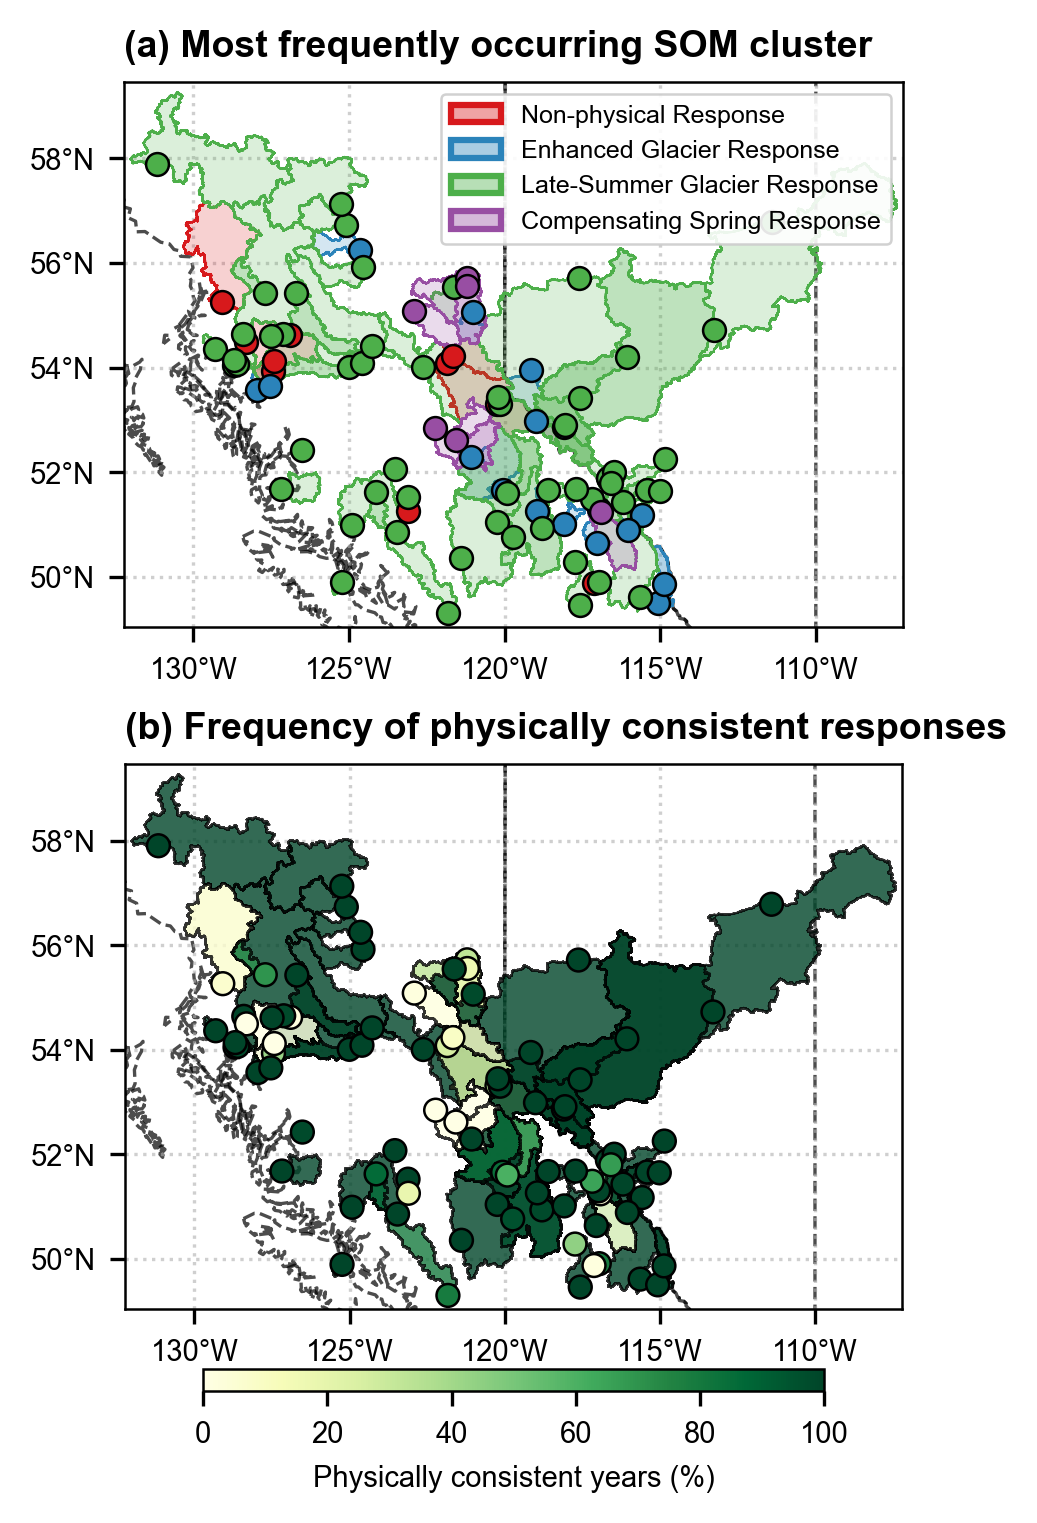

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import warnings
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

from src.config import RAW_DATA_DIR

warnings.filterwarnings('ignore')

# =========================================================
# 1. Load Station Metadata and Compute Realism Percentages
# =========================================================
print("Extracting SOM clusters and computing realism percentages...")

# 1a. Dominant Cluster
df_dominant = df_som_clusters.groupby('Station')['Cluster'].agg(lambda x: x.mode()[0]).reset_index()
df_dominant['Station'] = df_dominant['Station'].astype(str).str.strip().str.upper()

# 1b. Percentage of "Physically Realistic" years (Clusters 0 and 2)
realistic_clusters = [0, 2]
realistic_pct = df_som_clusters.groupby('Station').apply(
    lambda x: (x['Cluster'].isin(realistic_clusters)).mean() * 100
).reset_index(name='Realistic_Pct')
realistic_pct['Station'] = realistic_pct['Station'].astype(str).str.strip().str.upper()

# Pull coordinates directly from the pre-loaded attributes dataframe
df_geo = df_attr[['latitude', 'longitude']].copy()
df_geo.index = df_geo.index.astype(str).str.strip().str.upper()
df_geo = df_geo.rename(columns={'latitude': 'Latitude', 'longitude': 'Longitude'})

# Merge Lat/Lon, Dominant Cluster, and Realistic Percentage
df_map = pd.merge(df_dominant, df_geo, left_on='Station', right_index=True, how='inner')
df_map = pd.merge(df_map, realistic_pct, on='Station', how='inner')

# Create a GeoDataFrame for the Gauge Points
gdf_points = gpd.GeoDataFrame(
    df_map, 
    geometry=gpd.points_from_xy(df_map['Longitude'], df_map['Latitude']),
    crs="EPSG:4326"
)

# =========================================================
# 2. Load and Combine Basin Geometries (GeoPackages)
# =========================================================
print("Loading basin boundaries from GeoPackages...")

gpkg_files = ["MDA_ADP_05.gpkg", "MDA_ADP_07.gpkg", "MDA_ADP_08.gpkg"]
gdfs = []

for file_name in gpkg_files:
    file_path = RAW_DATA_DIR / "drainage_areas" / file_name
    try:
        gdf_part = gpd.read_file(file_path)
        gdfs.append(gdf_part)
        print(f"  -> Successfully loaded {file_name} ({len(gdf_part)} basins)")
    except Exception as e:
        print(f"  -> ⚠️ Failed to load {file_name}: {e}")

if not gdfs:
    raise FileNotFoundError("Could not load any basin geometries. Please check the file paths.")

gdf_basins = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs=gdfs[0].crs)

possible_cols = ['station_id', 'station', 'id', 'station_number', 'stationnum']
station_col = next((c for c in gdf_basins.columns if c.lower() in possible_cols), None)

if station_col:
    gdf_basins[station_col] = gdf_basins[station_col].astype(str).str.strip().str.upper()
else:
    raise ValueError("Could not find a station ID column in your basin shapefiles.")

# Merge the polygons with the cluster assignments
gdf_cluster_basins = gdf_basins.merge(df_map, left_on=station_col, right_on='Station', how='inner')

# Calculate area and sort so smallest basins plot on top
gdf_cluster_basins['calc_area'] = gdf_cluster_basins.to_crs("EPSG:3857").geometry.area
gdf_cluster_basins = gdf_cluster_basins.sort_values(by='calc_area', ascending=False)
gdf_cluster_basins = gdf_cluster_basins.to_crs("EPSG:4326")
print(f"Successfully matched and sorted {len(gdf_cluster_basins)} basin polygons.")

# =========================================================
# 3. Fetch Province Boundaries (BC and Alberta)
# =========================================================
print("Fetching geographic boundaries...")
try:
    url_provinces = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/canada.geojson"
    canada = gpd.read_file(url_provinces)
    bc_ab = canada[canada['name'].isin(['British Columbia', 'Alberta'])]
    bc_ab = bc_ab.to_crs("EPSG:4326")
except Exception as e:
    print(f"⚠️ Could not load province boundaries from web: {e}")
    bc_ab = None

# =========================================================
# 4. Plotting
# =========================================================
print("Rendering maps...")

# Reduced overall figure height to 13.5 cm and hspace to 0.15 to tighten vertical spacing
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(DOUBLE_COL, 13.5 * cm), gridspec_kw={'hspace': 0.25})

map_aspect_ratio = 1.0 / np.cos(np.radians(54))

cluster_colors = {
    3: '#d7191c',  # Red
    0: '#2b83ba',  # Blue
    2: '#4daf4a',  # Green
    1: '#984ea3'   # Purple
}

node_names = {
    (0, 0): "Enhanced Glacier Response",
    (0, 1): "Compensating Spring Response",
    (1, 0): "Late-Summer Glacier Response",
    (1, 1): "Non-physical Response"
}

# Ensure standard extents for both axes
if not gdf_cluster_basins.empty:
    minx, miny, maxx, maxy = gdf_cluster_basins.total_bounds
    xlim = (minx - 0.2, maxx + 0.2)
    ylim = (miny - 0.2, maxy + 0.2)
else:
    xlim, ylim = None, None

def format_lon(value, tick_number):
    return f"{abs(value):g}°W" if value < 0 else f"{value:g}°E"

def format_lat(value, tick_number):
    return f"{value:g}°N" if value > 0 else f"{abs(value):g}°S"

for ax in [ax1, ax2]:
    ax.set_aspect(map_aspect_ratio)
    if bc_ab is not None:
        bc_ab.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.8, linestyle='--', alpha=0.7, zorder=1)
    
    ax.xaxis.set_major_formatter(FuncFormatter(format_lon))
    ax.yaxis.set_major_formatter(FuncFormatter(format_lat))
    
    if xlim and ylim:
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        
    ax.grid(True, linestyle=':', alpha=0.6)

# ---------------------------------------------------------
# PANEL (a) - Dominant Cluster
# ---------------------------------------------------------
ax1.set_title('(a) Most frequently occurring SOM cluster', loc='left', fontweight='bold', fontsize=9)
legend_elements = []

for cluster_id, color in cluster_colors.items():
    qx = cluster_id // 2
    qy = cluster_id % 2
    node_name = node_names[(qx, qy)]
    
    subset_poly = gdf_cluster_basins[gdf_cluster_basins['Cluster'] == cluster_id]
    
    if not subset_poly.empty:
        fill_color = mcolors.to_rgba(color, alpha=0.20)
        subset_poly.plot(ax=ax1, facecolor=fill_color, edgecolor=color, linewidth=0.5, zorder=2)
        
    subset_pts = gdf_points[gdf_points['Cluster'] == cluster_id]
    if not subset_pts.empty:
        subset_pts.plot(ax=ax1, color=color, markersize=30, edgecolor='black', linewidth=0.6, zorder=3)
        legend_elements.append(Patch(facecolor=mcolors.to_rgba(color, alpha=0.4), edgecolor=color, linewidth=1.5, label=node_name))

# Overridden legend font size to 7pt
ax1.legend(handles=legend_elements, loc='upper right', framealpha=0.9, edgecolor='#ccc', fontsize=6)

# ---------------------------------------------------------
# PANEL (b) - Physically Realistic Percentage
# ---------------------------------------------------------
ax2.set_title('(b) Frequency of physically consistent responses', loc='left', fontweight='bold', fontsize=9)

cmap = plt.get_cmap('YlGn')

# Plot Basins
gdf_cluster_basins.plot(
    ax=ax2, 
    column='Realistic_Pct', 
    cmap=cmap, 
    vmin=0, vmax=100,
    edgecolor='black', 
    linewidth=0.5, 
    alpha=0.8,
    zorder=2
)

# Plot Gauges
gdf_points.plot(
    ax=ax2, 
    column='Realistic_Pct', 
    cmap=cmap,
    vmin=0, vmax=100,
    markersize=30, 
    edgecolor='black', 
    linewidth=0.6, 
    zorder=3
)

# Colorbar Formatting
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=100))
sm._A = []

# Shifted the colorbar back to -0.15 since hspace was reduced
cax = ax2.inset_axes([0.1, -0.15, 0.8, 0.04]) 
cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
# Removed bold fontweight and explicitly set fontsize to 8pt
cbar.set_label('Physically consistent years (%)', fontsize=7)

plt.savefig('..//figures/fig05.png')
plt.show()

**Figure 6:** Correlations and evaluation metrics

Extracting mean and bounds for August...
Converting units across all ensemble bounds...
Assembling plotting dataset...
Generating Scatter Grid...


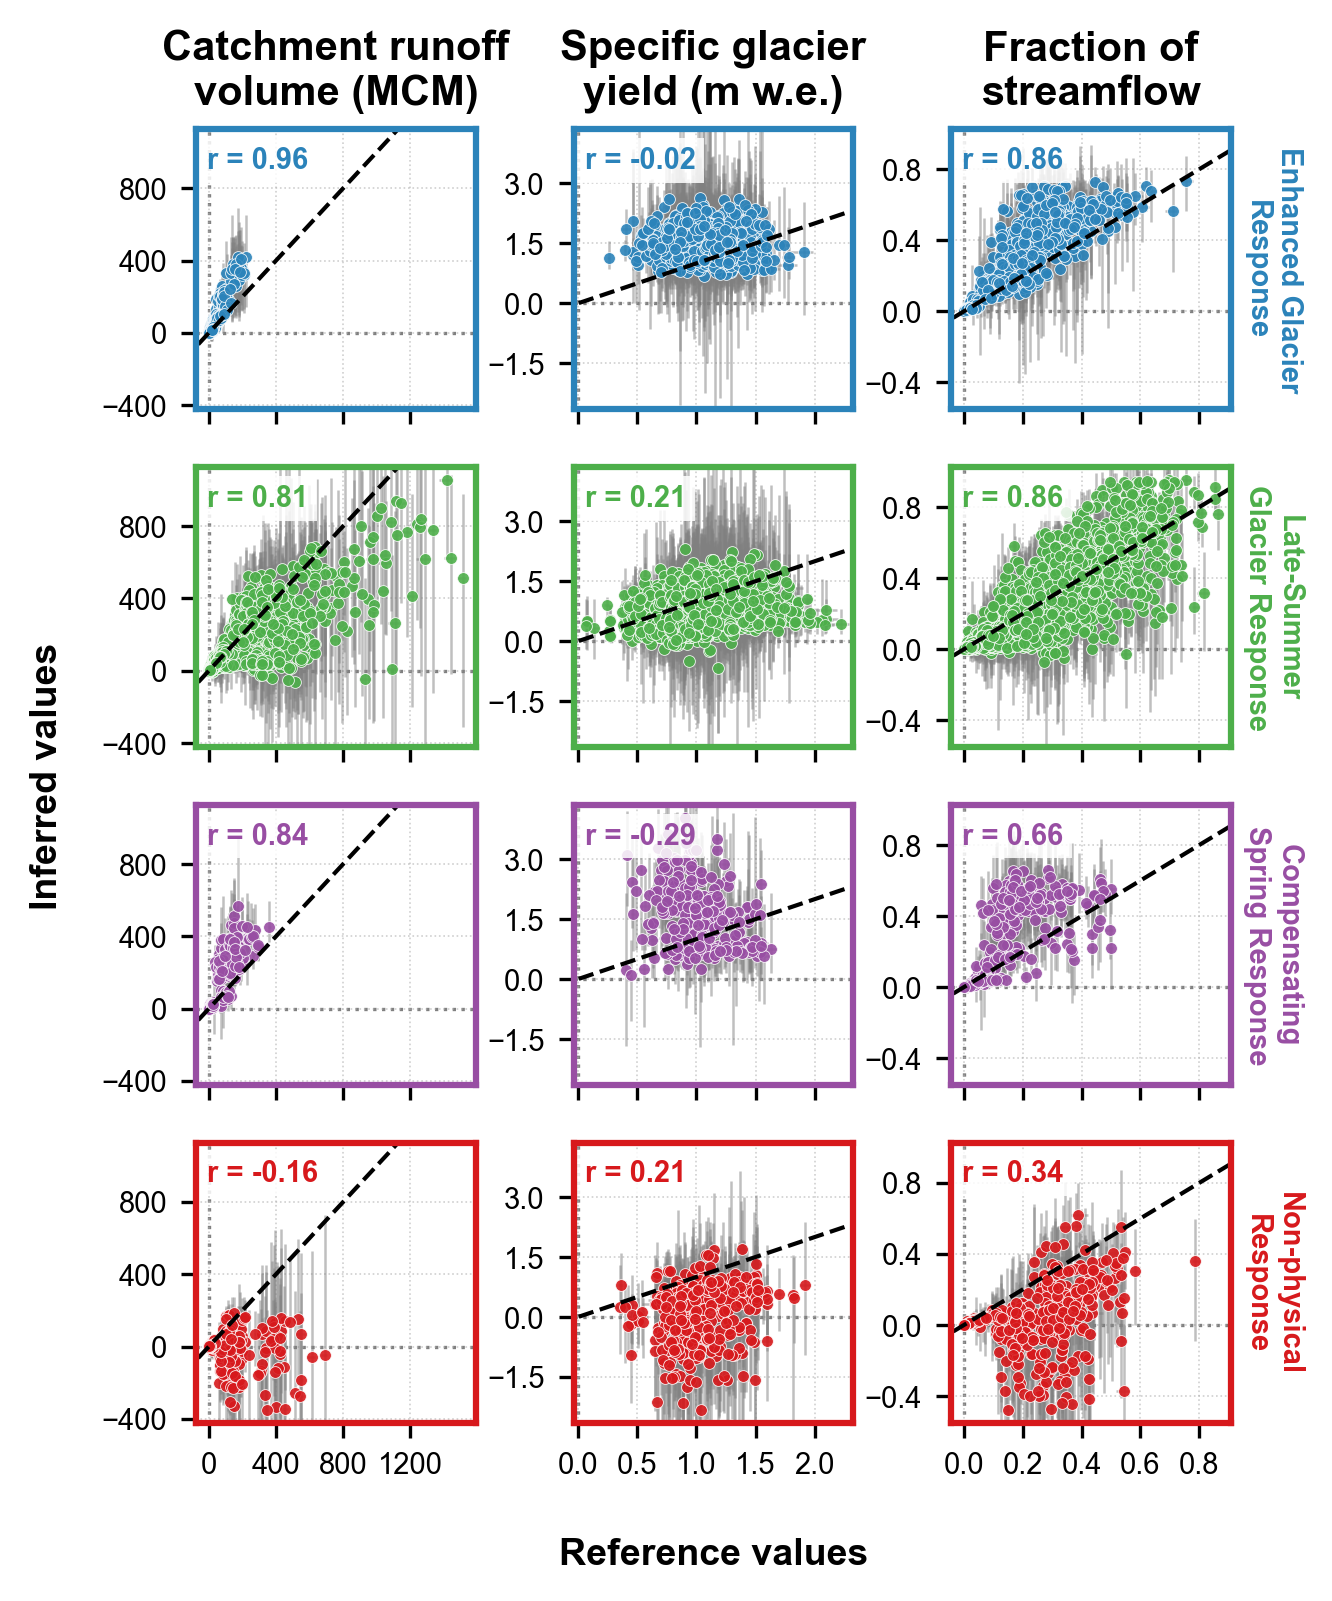

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
import warnings

warnings.filterwarnings('ignore')

MONTH = 8 # August

# =========================================================
# 1. Isolate August Data & Extract Range Bounds
# =========================================================
print("Extracting mean and bounds for August...")

aug_mask_daily = (dq_pred.index.month == MONTH)
aug_mask_monthly = (mb_pred.index.month == MONTH)

# Extract Mean
dq_pred_aug_sum = dq_pred[aug_mask_daily].groupby(dq_pred[aug_mask_daily].index.year).sum()
mb_pred_mcm_aug_sum = mb_pred[aug_mask_monthly].groupby(mb_pred[aug_mask_monthly].index.year).sum()

# Extract Min/Max from the provided range variables
dq_min = dq_pred_range.xs('min', level=1, axis=1)
dq_max = dq_pred_range.xs('max', level=1, axis=1)
mb_min = mb_pred_range.xs('min', level=1, axis=1)
mb_max = mb_pred_range.xs('max', level=1, axis=1)

dq_min_aug_sum = dq_min[aug_mask_daily].groupby(dq_min[aug_mask_daily].index.year).sum()
dq_max_aug_sum = dq_max[aug_mask_daily].groupby(dq_max[aug_mask_daily].index.year).sum()
mb_min_aug_sum = mb_min[aug_mask_monthly].groupby(mb_min[aug_mask_monthly].index.year).sum()
mb_max_aug_sum = mb_max[aug_mask_monthly].groupby(mb_max[aug_mask_monthly].index.year).sum()

# =========================================================
# 2. Convert Units (Mean, Min, Max)
# =========================================================
print("Converting units across all ensemble bounds...")

# --- Predicted Metric 1: MCM ---
areas = df_attr.loc[dq_pred_aug_sum.columns, 'basin_area_km2']
dq_pred_mcm_aug_sum = dq_pred_aug_sum * areas * 0.001
dq_min_mcm = dq_min_aug_sum * areas * 0.001
dq_max_mcm = dq_max_aug_sum * areas * 0.001

# --- Predicted Metric 2: m ---
# MCM (10^6 m^3) / Area (10^6 m^2) = meters
glac_areas = df_attr.loc[dq_pred_mcm_aug_sum.columns, 'glacier_area_km2']
dq_pred_m_glacier_aug_sum = dq_pred_mcm_aug_sum / glac_areas
dq_min_m = dq_min_mcm / glac_areas
dq_max_m = dq_max_mcm / glac_areas

# --- Predicted Metric 3: Fraction ---
df_pred_glac = df_pred[glaciated_stations]
pred_q_aug = df_pred_glac[aug_mask_daily].groupby(df_pred_glac[aug_mask_daily].index.year).sum()
dq_pred_frac_aug_sum = dq_pred_aug_sum / pred_q_aug
dq_min_pct = dq_min_aug_sum / pred_q_aug
dq_max_pct = dq_max_aug_sum / pred_q_aug

# --- Ground Truth Conversions (Flipping Sign) ---
act_mcm = -mb_pred_mcm_aug_sum
act_mcm_min = -mb_max_aug_sum 
act_mcm_max = -mb_min_aug_sum 

act_m = act_mcm / glac_areas
act_m_min = act_mcm_min / glac_areas
act_m_max = act_mcm_max / glac_areas

q_obs_aug_sum = q_obs_filtered[aug_mask_daily].groupby(q_obs_filtered[aug_mask_daily].index.year).sum()
q_obs_vol = q_obs_aug_sum * df_attr.loc[q_obs_aug_sum.columns, 'basin_area_km2'] * 0.001

act_pct = act_mcm / q_obs_vol
act_pct_min = act_mcm_min / q_obs_vol
act_pct_max = act_mcm_max / q_obs_vol

# =========================================================
# 3. Stack Data for Plotting
# =========================================================
print("Assembling plotting dataset...")

def stack_metric(df, name):
    stacked = df.stack().reset_index()
    stacked.columns = ['Year', 'Station', name]
    return stacked.set_index(['Year', 'Station'])

plot_df = pd.concat([
    stack_metric(dq_pred_mcm_aug_sum, 'Pred_MCM'),
    stack_metric(dq_min_mcm, 'Pred_MCM_min'),
    stack_metric(dq_max_mcm, 'Pred_MCM_max'),
    
    stack_metric(act_mcm, 'Act_MCM'),
    stack_metric(act_mcm_min, 'Act_MCM_min'),
    stack_metric(act_mcm_max, 'Act_MCM_max'),
    
    stack_metric(dq_pred_m_glacier_aug_sum, 'Pred_m'),
    stack_metric(dq_min_m, 'Pred_m_min'),
    stack_metric(dq_max_m, 'Pred_m_max'),
    
    stack_metric(act_m, 'Act_m'),
    stack_metric(act_m_min, 'Act_m_min'),
    stack_metric(act_m_max, 'Act_m_max'),
    
    stack_metric(dq_pred_frac_aug_sum, 'Pred_Pct'),
    stack_metric(dq_min_pct, 'Pred_Pct_min'),
    stack_metric(dq_max_pct, 'Pred_Pct_max'),
    
    stack_metric(act_pct, 'Act_Pct'),
    stack_metric(act_pct_min, 'Act_Pct_min'),
    stack_metric(act_pct_max, 'Act_Pct_max')
], axis=1).reset_index()

# Merge SOM Clusters
df_som_clusters['Station'] = df_som_clusters['Station'].astype(str).str.strip().str.upper()

plot_df = pd.merge(plot_df, df_som_clusters[['Year', 'Station', 'Cluster']], on=['Year', 'Station'], how='inner')

# Clean up infinite/wild outliers for plot readability
plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna()
plot_df = plot_df[(plot_df['Pred_Pct'] >= -0.5) & (plot_df['Pred_Pct'] <= 1.5)]
plot_df = plot_df[(plot_df['Act_Pct'] >= -0.5) & (plot_df['Act_Pct'] <= 1.5)]


# =========================================================
# 4. Plotting: The 4x3 Master Grid
# =========================================================
print("Generating Scatter Grid...")

fig = plt.figure(figsize=(DOUBLE_COL, 13.5 * cm))

gs = gridspec.GridSpec(4, 3, hspace=0.15, wspace=0.35)

cluster_colors = {
    0: '#2b83ba',  # Blue
    1: '#984ea3',  # Purple
    2: '#4daf4a',  # Green
    3: '#d7191c'   # Red
}

som_node_names = {
    0: "Enhanced Glacier\nResponse",
    1: "Compensating\nSpring Response",
    2: "Late-Summer\nGlacier Response",
    3: "Non-physical\nResponse"
}

plot_configs = [
    ('Pred_MCM', 'Act_MCM', 'Catchment runoff\nvolume (MCM)'),
    ('Pred_m', 'Act_m', 'Specific glacier\nyield (m w.e.)'),
    ('Pred_Pct', 'Act_Pct', 'Fraction of\nstreamflow')
]

# --- INVISIBLE SUPER AXES ---
ax_common = fig.add_subplot(gs[:, :], frameon=False, zorder=-1)
ax_common.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
ax_common.grid(False)
ax_common.set_ylabel('Inferred values', fontweight='bold', labelpad=15)
ax_common.set_xlabel('Reference values', fontweight='bold', labelpad=12)

# Precalculate plotting limits independently for X and Y
col_limits = []
for config in plot_configs:
    y_col, x_col, _ = config
    
    x_min, x_max = plot_df[x_col].min(), plot_df[x_col].max()
    y_min, y_max = plot_df[y_col].min(), plot_df[y_col].max()
    
    x_margin = (x_max - x_min) * 0.05
    y_margin = (y_max - y_min) * 0.05
    
    col_limits.append({
        'x': (min(0, x_min - x_margin), x_max + x_margin),
        'y': (min(0, y_min - y_margin), y_max + y_margin)
    })

# --- PLOTTING LOOP ---
# Enforced order: Blue (0), Green (2), Purple (1), Red (3)
for row_idx, cluster_id in enumerate([0, 2, 1, 3]):
    c_color = cluster_colors[cluster_id]
    subset = plot_df[plot_df['Cluster'] == cluster_id]
    
    for col_idx, config in enumerate(plot_configs):
        y_col, x_col, col_title = config
        ax = fig.add_subplot(gs[row_idx, col_idx])
        
        ax.set_box_aspect(1)
        
        # Cluster Colored Borders
        for spine in ax.spines.values():
            spine.set_edgecolor(c_color)
            spine.set_linewidth(1.5)
            spine.set_zorder(10)
            
        if len(subset) == 0:
            ax.set_xticks([])
            ax.set_yticks([])
            continue
            
        # Error Bars
        x_err_low = np.clip(subset[x_col] - subset[x_col+'_min'], 0, None)
        x_err_high = np.clip(subset[x_col+'_max'] - subset[x_col], 0, None)
        y_err_low = np.clip(subset[y_col] - subset[y_col+'_min'], 0, None)
        y_err_high = np.clip(subset[y_col+'_max'] - subset[y_col], 0, None)
        
        ax.errorbar(
            subset[x_col], subset[y_col], 
            xerr=[x_err_low, x_err_high], yerr=[y_err_low, y_err_high],
            fmt='none', ecolor='gray', elinewidth=0.6, alpha=0.5, zorder=2
        )
        
        # Scatter
        ax.scatter(
            subset[x_col], subset[y_col], 
            color=c_color, alpha=0.9, edgecolors='white', linewidths=0.2, s=8, zorder=3
        )
        
        # 1:1 Line
        line_min = min(col_limits[col_idx]['x'][0], col_limits[col_idx]['y'][0])
        line_max = max(col_limits[col_idx]['x'][1], col_limits[col_idx]['y'][1])
        ax.plot([line_min, line_max], [line_min, line_max], color='black', linestyle='--', linewidth=1.0, zorder=4)
        
        ax.axhline(0, color='gray', linestyle=':', linewidth=0.8, zorder=1)
        ax.axvline(0, color='gray', linestyle=':', linewidth=0.8, zorder=1)
        
        # Axis limits and grid
        ax.set_xlim(col_limits[col_idx]['x'])
        ax.set_ylim(col_limits[col_idx]['y'])
        ax.grid(True, linestyle=':', alpha=0.6, lw=0.4, zorder=0)
        
        # Enforce ~5 tick marks
        ax.xaxis.set_major_locator(MaxNLocator(5))
        ax.yaxis.set_major_locator(MaxNLocator(5))
        
        # Top-Left correlation
        r_val = subset[x_col].corr(subset[y_col]) if len(subset) > 1 else np.nan
        text_label = f'r = {r_val:.2f}' if not np.isnan(r_val) else 'N=1'
        ax.text(0.04, 0.94, text_label, transform=ax.transAxes, fontweight='bold', color=c_color, 
                bbox=dict(facecolor='white', alpha=0.85, edgecolor='none', pad=2), va='top', zorder=5)

        # Internal tick masking
        if row_idx < 3:
            ax.tick_params(labelbottom=False)
            
        # Top Row Column Titles
        if row_idx == 0:
            ax.set_title(col_title, fontweight='bold')

        # Right Column Cluster Names
        if col_idx == 2:
            ax.text(1.15, 0.5, som_node_names[cluster_id], transform=ax.transAxes, 
                    rotation=-90, va='center', ha='center', fontweight='bold', color=c_color)

plt.subplots_adjust(top=0.92, bottom=0.10, left=0.12, right=0.85)
plt.savefig('..//figures/fig06.pdf')
plt.show()

**Figure 7:** Boxplots of attributes vs catchment-specific correlation and MBE

Computing station-level correlations and MBE for Specific Yield (m w.e.)...

--- Group Statistics (Counts and Medians) ---

[Glaciation_Group]
  0–1 %: N = 39 | Median r = 0.239 | Median MBE = -0.287
  1–5 %: N = 31 | Median r = 0.520 | Median MBE = 0.091
  > 5 %: N = 17 | Median r = 0.675 | Median MBE = 0.179

[Distance_Group]
  0–50 km: N = 38 | Median r = 0.538 | Median MBE = -0.050
  50–150 km: N = 37 | Median r = 0.400 | Median MBE = 0.024
  > 150 km: N = 12 | Median r = 0.364 | Median MBE = -0.563

[Consistent_Group]
  0–50 %: N = 17 | Median r = 0.385 | Median MBE = -0.448
  50–99 %: N = 14 | Median r = 0.405 | Median MBE = -0.171
  > 99 %: N = 56 | Median r = 0.513 | Median MBE = 0.036
---------------------------------------------



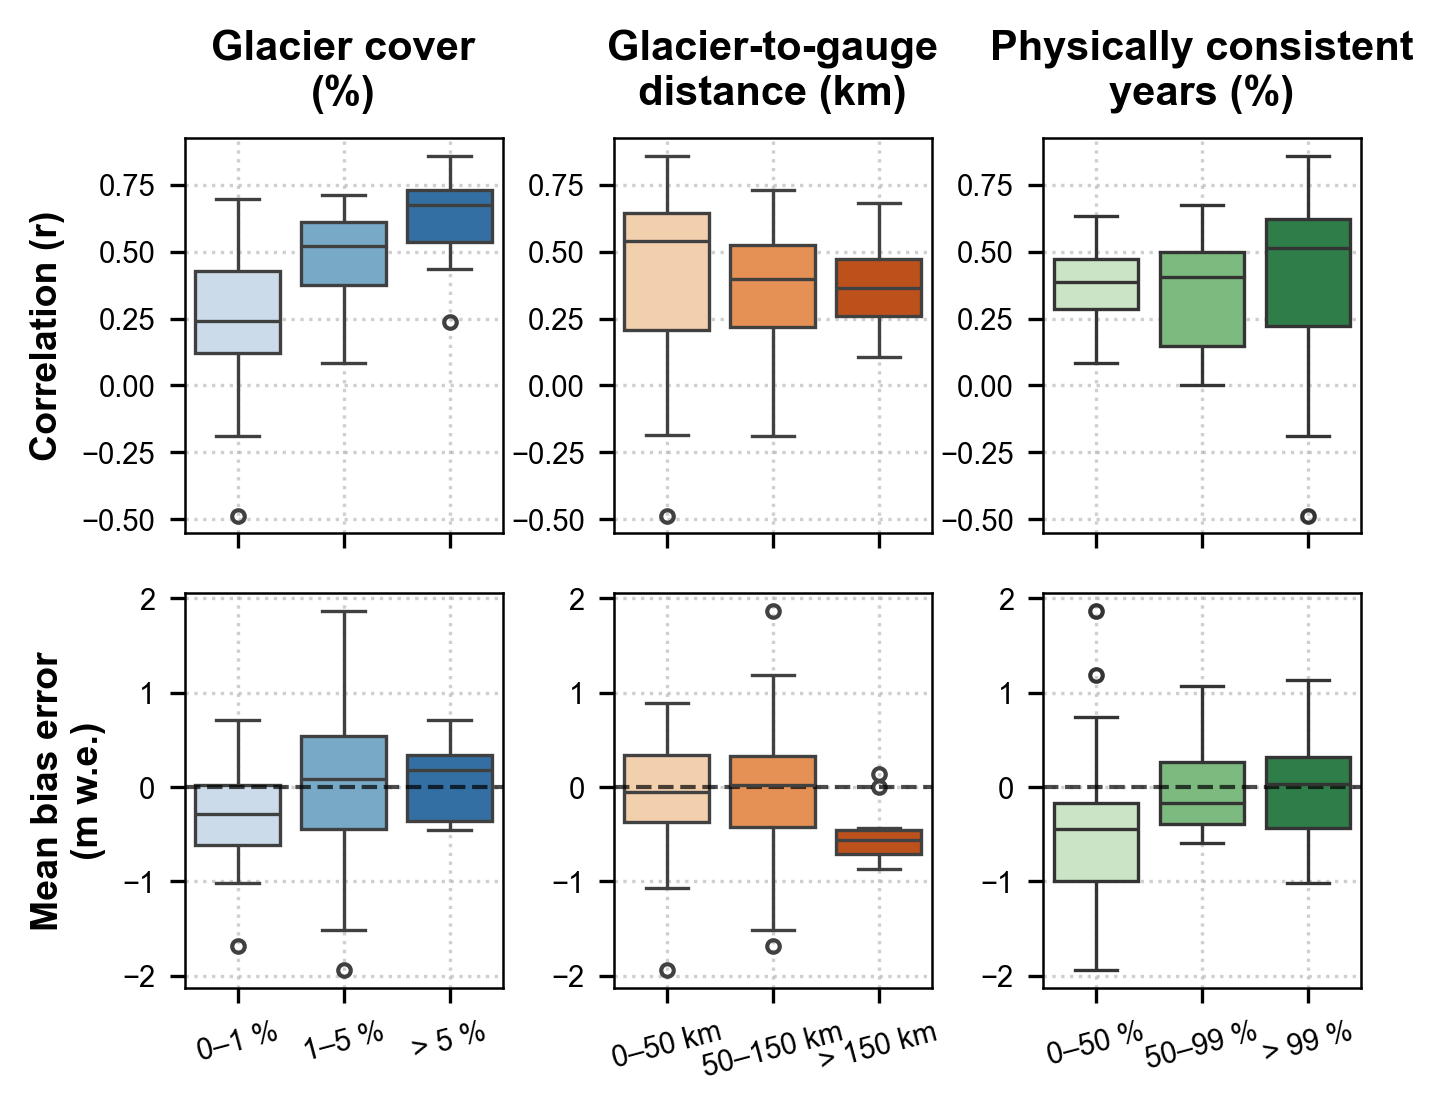

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# =========================================================
# 2. Compute Station Correlations (df_station_corrs)
# =========================================================
print("Computing station-level correlations and MBE for Specific Yield (m w.e.)...")

# Evaluate based on Specific Yield (m)
PRED_COL = 'Pred_m'
ACT_COL = 'Act_m'

stats_list = []
for station, group in plot_df.groupby('Station'):
    valid_data = group.dropna(subset=[PRED_COL, ACT_COL])
    if len(valid_data) > 1:
        r_val = valid_data[PRED_COL].corr(valid_data[ACT_COL])
        mbe_val = (valid_data[PRED_COL] - valid_data[ACT_COL]).mean()
    else:
        r_val = np.nan
        mbe_val = np.nan
        
    stats_list.append({'Station': station, 'r': r_val, 'MBE': mbe_val})

df_station_corrs = pd.DataFrame(stats_list)

# Standardize index strings for safe merging
df_station_corrs['Station'] = df_station_corrs['Station'].astype(str).str.strip().str.upper()
df_attr.index = df_attr.index.astype(str).str.strip().str.upper()
df_som_clusters['Station'] = df_som_clusters['Station'].astype(str).str.strip().str.upper()

# Calculate and Merge Glacier Percentage
df_station_corrs['Glacier_Pct'] = (
    df_attr.loc[df_station_corrs['Station'], 'glacier_area_km2'].values / 
    df_attr.loc[df_station_corrs['Station'], 'basin_area_km2'].values
) * 100

# Merge Average Glacier Distance
df_station_corrs['avg_glacier_dist_km'] = df_attr.loc[df_station_corrs['Station'], 'avg_glacier_dist_km'].values

# Calculate and Merge Physically Consistent Percentage
consistent_clusters = [0, 2]
consistent_pct = df_som_clusters.groupby('Station').apply(
    lambda x: (x['Cluster'].isin(consistent_clusters)).mean() * 100
).reset_index(name='Consistent_Pct')
consistent_pct['Station'] = consistent_pct['Station'].astype(str).str.strip().str.upper()

df_station_corrs = pd.merge(df_station_corrs, consistent_pct, on='Station', how='left')

# =========================================================
# 3. Create Bins and Labels
# =========================================================
glacier_bins = [-np.inf, 1, 5, np.inf]
glacier_labels_base = ['0–1 %', '1–5 %', '> 5 %']
df_station_corrs['Glaciation_Group'] = pd.cut(df_station_corrs['Glacier_Pct'], bins=glacier_bins, labels=glacier_labels_base)

distance_bins = [-np.inf, 50, 150, np.inf]
distance_labels_base = ['0–50 km', '50–150 km', '> 150 km']
df_station_corrs['Distance_Group'] = pd.cut(df_station_corrs['avg_glacier_dist_km'], bins=distance_bins, labels=distance_labels_base)

# Adjusted bins for physically consistent years
consistent_bins = [-np.inf, 50, 99, np.inf]
consistent_labels_base = ['0–50 %', '50–99 %', '> 99 %']
df_station_corrs['Consistent_Group'] = pd.cut(df_station_corrs['Consistent_Pct'], bins=consistent_bins, labels=consistent_labels_base)

# =========================================================
# 4. Terminal Reporting
# =========================================================
print("\n--- Group Statistics (Counts and Medians) ---")

def report_group_stats(group_col, labels_base):
    print(f"\n[{group_col}]")
    for label in labels_base:
        subset = df_station_corrs[df_station_corrs[group_col] == label]
        n_count = len(subset.dropna(subset=['r', 'MBE']))
        r_med = subset['r'].median() if n_count > 0 else np.nan
        mbe_med = subset['MBE'].median() if n_count > 0 else np.nan
        
        print(f"  {label}: N = {n_count} | Median r = {r_med:.3f} | Median MBE = {mbe_med:.3f}")

report_group_stats('Glaciation_Group', glacier_labels_base)
report_group_stats('Distance_Group', distance_labels_base)
report_group_stats('Consistent_Group', consistent_labels_base)
print("---------------------------------------------\n")

# =========================================================
# 5. Plotting: The 2x3 Grid
# =========================================================
fig, axes = plt.subplots(2, 3, figsize=(DOUBLE_COL, 10.0 * cm), gridspec_kw={'hspace': 0.15, 'wspace': 0.35})

# --- Row 1: Correlation (r) ---
sns.boxplot(data=df_station_corrs, x='Glaciation_Group', y='r', ax=axes[0, 0], palette='Blues', linewidth=0.8, fliersize=3)
sns.boxplot(data=df_station_corrs, x='Distance_Group', y='r', ax=axes[0, 1], palette='Oranges', linewidth=0.8, fliersize=3)
sns.boxplot(data=df_station_corrs, x='Consistent_Group', y='r', ax=axes[0, 2], palette='Greens', linewidth=0.8, fliersize=3)

# --- Row 2: Mean Bias Error (MBE) ---
sns.boxplot(data=df_station_corrs, x='Glaciation_Group', y='MBE', ax=axes[1, 0], palette='Blues', linewidth=0.8, fliersize=3)
sns.boxplot(data=df_station_corrs, x='Distance_Group', y='MBE', ax=axes[1, 1], palette='Oranges', linewidth=0.8, fliersize=3)
sns.boxplot(data=df_station_corrs, x='Consistent_Group', y='MBE', ax=axes[1, 2], palette='Greens', linewidth=0.8, fliersize=3)

# --- Subplot Formatting ---
col_titles = [
    'Glacier cover\n(%)',
    'Glacier-to-gauge\ndistance (km)',
    'Physically consistent\nyears (%)'
]

for row in range(2):
    for col in range(3):
        ax = axes[row, col]
        ax.set_xlabel('')
        ax.grid(True, linestyle=':', alpha=0.6, zorder=0)
        
        # Format Y-axis labels and hide internal ones
        if col > 0:
            ax.set_ylabel('')
        else:
            if row == 0:
                ax.set_ylabel('Correlation (r)', fontweight='bold')
            else:
                ax.set_ylabel('Mean bias error\n(m w.e.)', fontweight='bold')
                
        # Format Top Row titles and hide X-ticks
        if row == 0:
            ax.set_title(col_titles[col], fontweight='bold', pad=8)
            ax.tick_params(labelbottom=False)
            
        # Format Bottom Row (MBE) specific elements
        if row == 1:
            # Add dashed line at 0 for bias
            ax.axhline(0, color='black', linestyle='--', linewidth=1.0, alpha=0.7, zorder=2)
            # Rotate X-ticks slightly to prevent overlapping
            ax.tick_params(axis='x', rotation=15)

plt.subplots_adjust(top=0.90, bottom=0.18, left=0.12, right=0.95)
plt.savefig('..//figures/fig07.pdf')
plt.show()

**Figure 8:**

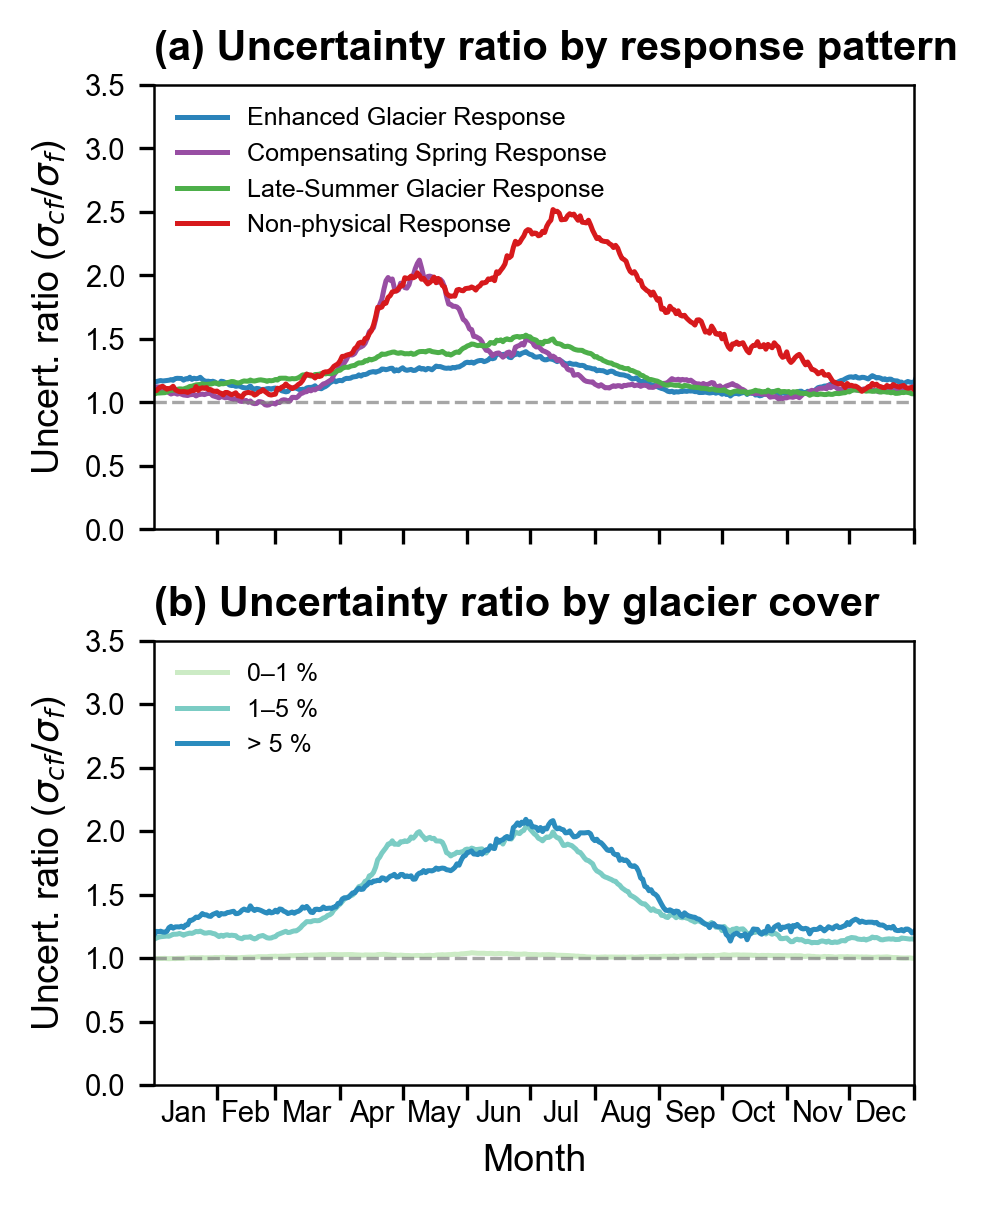

In [24]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

# =========================================================
# 1. Map SOM outputs to Modal Catchment Clusters
# =========================================================
cluster_map = {
    0: 'Enhanced Glacier Response',
    1: 'Compensating Spring Response',
    2: 'Late-Summer Glacier Response',
    3: 'Non-physical Response'
}

df_som_clusters['Cluster_Name'] = df_som_clusters['Cluster'].map(cluster_map)
modal_clusters = df_som_clusters.groupby('Station')['Cluster_Name'].agg(lambda x: x.mode()[0])

# =========================================================
# 2. Prep Data for Plotting (Means Only)
# =========================================================
doy_ratio = df_uncertainty_ratio[glaciated_stations].groupby(df_uncertainty_ratio.index.dayofyear).mean()

# Calculate statistics by Cluster
cluster_stats = {}
for cluster_name in cluster_map.values():
    cols = modal_clusters[modal_clusters == cluster_name].index.intersection(glaciated_stations)
    if len(cols) > 0:
        mean = doy_ratio[cols].mean(axis=1)
        cluster_stats[cluster_name] = {'mean': mean}

# Calculate statistics by Glacier Cover
bins = [0, 1, 5, 100]
labels = ['0–1 %', '1–5 %', '> 5 %']
cover_groups = pd.cut(df_attr.loc[glaciated_stations, 'glacier_pct'], bins=bins, labels=labels)

cover_stats = {}
for group in labels:
    cols = cover_groups[cover_groups == group].index.intersection(glaciated_stations)
    if len(cols) > 0:
        mean = doy_ratio[cols].mean(axis=1)
        cover_stats[group] = {'mean': mean}

# =========================================================
# 3. Plotting
# =========================================================
cm = 1 / 2.54
SINGLE_COL = 8.3 * cm

# Reduced hspace to 0.25 and added sharey=True
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(SINGLE_COL, 11 * cm), sharex=True, sharey=True,
                               gridspec_kw={'hspace': 0.25})

cluster_colors = {
    'Late-Summer Glacier Response': '#4daf4a', 
    'Enhanced Glacier Response': '#2b83ba',
    'Compensating Spring Response': '#984ea3',
    'Non-physical Response': '#d7191c'
}

cover_colors = {
    '0–1 %': '#ccebc5',
    '1–5 %': '#7bccc4',
    '> 5 %': '#2b8cbe'
}

# --- Panel A: By Cluster ---
for cluster, stats in cluster_stats.items():
    color = cluster_colors.get(cluster, 'k')
    ax1.plot(stats['mean'].index, stats['mean'], label=cluster, color=color, lw=1.2)

ax1.axhline(1.0, color='gray', linestyle='--', lw=0.8, alpha=0.7)
ax1.set_ylabel(r'Uncert. ratio ($\sigma_{cf} / \sigma_f$)')
ax1.set_title('(a) Uncertainty ratio by response pattern', loc='left', fontweight='bold')
ax1.legend(loc='upper left', frameon=False, prop={'size': 6})

# --- Panel B: By Glacier Cover ---
for group, stats in cover_stats.items():
    color = cover_colors.get(group, 'k')
    ax2.plot(stats['mean'].index, stats['mean'], label=group, color=color, lw=1.2)

ax2.axhline(1.0, color='gray', linestyle='--', lw=0.8, alpha=0.7)
ax2.set_ylabel(r'Uncert. ratio ($\sigma_{cf} / \sigma_f$)')
ax2.set_xlabel('Month')
ax2.set_title('(b) Uncertainty ratio by glacier cover', loc='left', fontweight='bold')
ax2.legend(loc='upper left', frameon=False, prop={'size': 6})

# --- Centered Month Formatting & Y-Axis Limits ---
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_bounds = [0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334, 365]
month_midpoints = [(month_bounds[m] + month_bounds[m+1]) // 2 for m in range(12)]

for ax in [ax1, ax2]:
    # Fix y-scale to leave room for the legend at the top
    ax.set_ylim(0, 3.5)
    
    # Set major ticks to month boundaries but hide the text
    ax.set_xticks(month_bounds)
    ax.set_xticklabels([])
    
    # Set minor ticks to midpoints and apply the month labels
    ax.set_xticks(month_midpoints, minor=True)
    # Hide the minor tick marks so just the centered text shows
    ax.tick_params(axis='x', which='minor', length=0) 

# Only apply the actual text labels to the bottom axis
ax2.set_xticklabels(months, minor=True, ha='center')

plt.xlim(1, 365)
plt.savefig(fig_dir / 'fig08.pdf')
plt.show()

## Supplementary

Factual vs. counterfactual hydrographs

Extracting data for Station 05DA009...
Calculating DL ensemble predictions and uncertainties...
Generating plots...


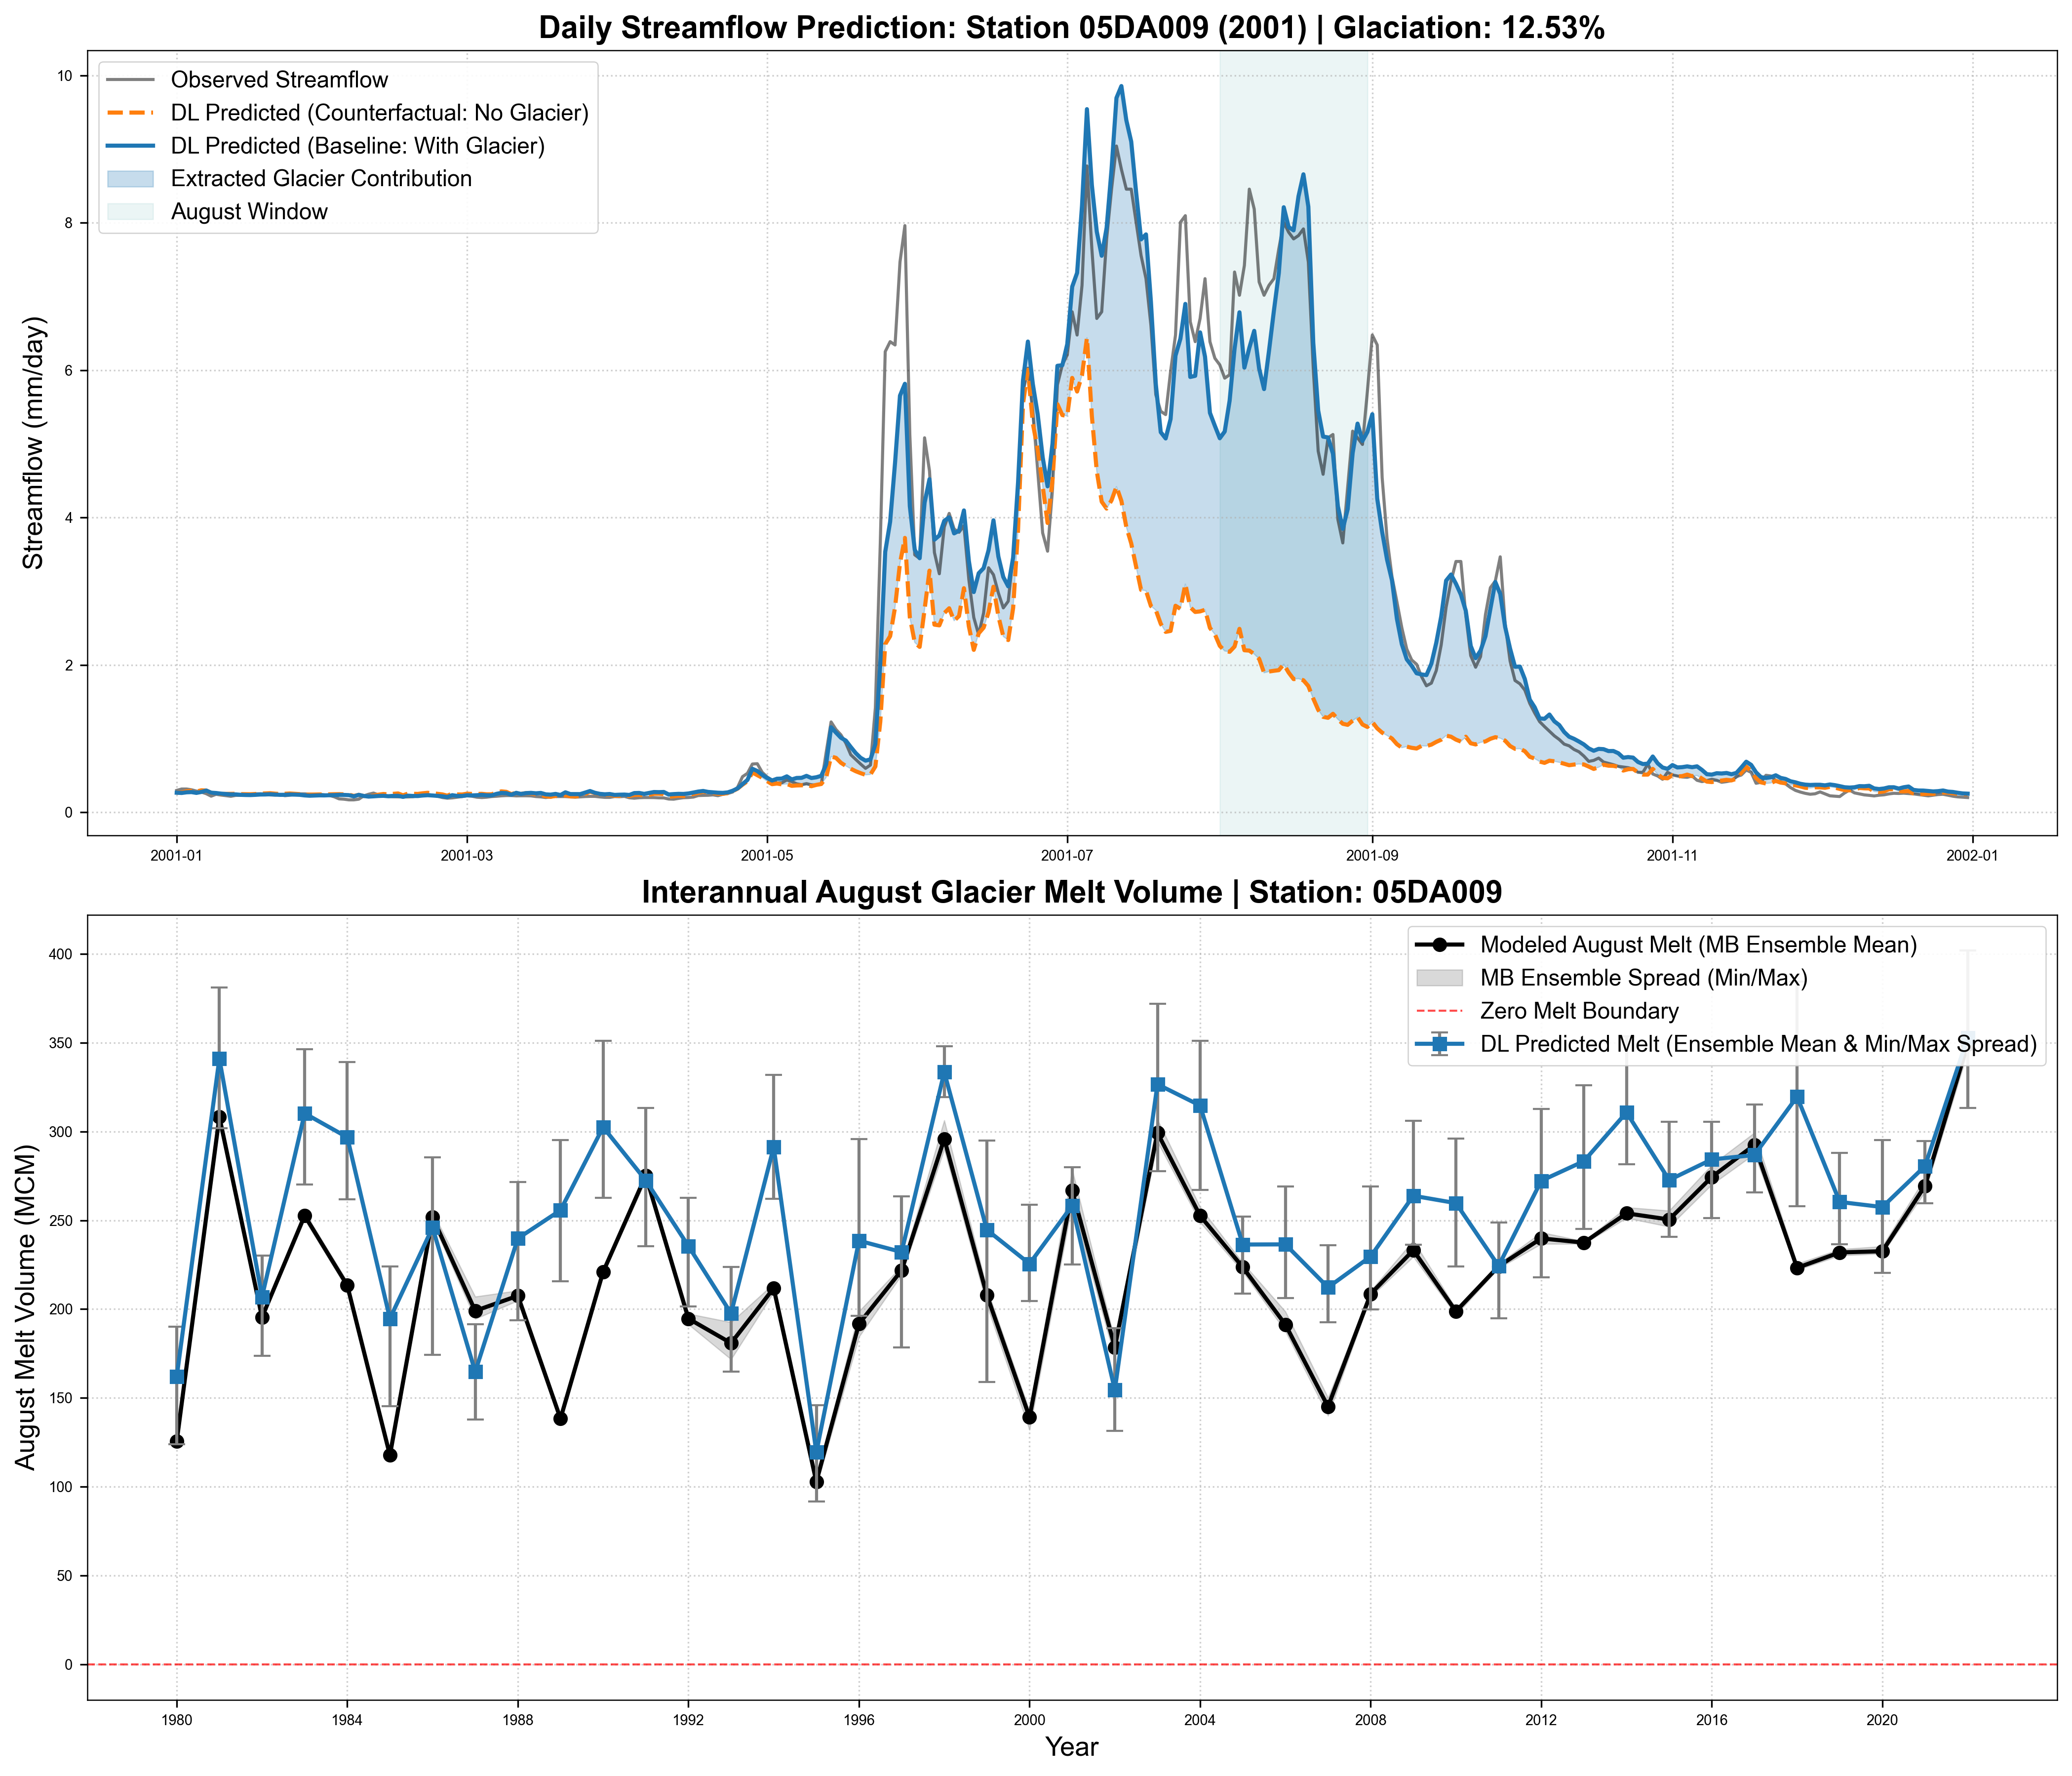

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# =========================================================
# 1. USER INPUTS
# =========================================================
TARGET_STATION = '05DA009'  # Change to explore different stations
TARGET_YEAR = 2001          # Change to explore different years

# =========================================================
# 2. Extract Target Data from Pre-loaded Environment
# =========================================================
print(f"Extracting data for Station {TARGET_STATION}...")

basin_area = df_attr.loc[TARGET_STATION, 'basin_area_km2']
glac_pct = df_attr.loc[TARGET_STATION, 'glacier_pct']

# Observations are already in mm/day per the environment template
obs_series = df_obs[TARGET_STATION]

# Extract and process the 3-member Mass Balance Ensemble
list_mb_aug_yearly = []
for mb_member in df_mbs:
    # Extract August data, and multiply by -1 to flip sign from mass loss to positive melt
    mb_aug = -mb_member[TARGET_STATION][mb_member.index.month == 8]
    mb_aug_sum = mb_aug.groupby(mb_aug.index.year).sum()
    list_mb_aug_yearly.append(mb_aug_sum)

# Aggregate MB ensemble
df_act_aug_yearly = pd.concat(list_mb_aug_yearly, axis=1)
act_aug_mcm_mean = df_act_aug_yearly.mean(axis=1)

# =========================================================
# 3. Process DL Ensemble Predictions and Uncertainty Spread
# =========================================================
print("Calculating DL ensemble predictions and uncertainties...")

list_aug_mcm_yearly = []

# Iterate through the pre-loaded lists of DL ensemble DataFrames
for pred_member, cf_member in zip(df_preds, df_cf_preds):
    pred = pred_member[TARGET_STATION]
    noglac = cf_member[TARGET_STATION]
    
    # Calculate yearly August MCM for this specific ensemble member
    diff_mm = pred - noglac
    aug_diff_mm = diff_mm[diff_mm.index.month == 8].groupby(diff_mm[diff_mm.index.month == 8].index.year).sum()
    
    # Convert mm over the basin to Million Cubic Meters (MCM)
    aug_mcm = aug_diff_mm * basin_area * 0.001
    list_aug_mcm_yearly.append(aug_mcm)

# Aggregate yearly August melt across the DL ensemble
df_aug_yearly = pd.concat(list_aug_mcm_yearly, axis=1)

# Extract deterministic daily means directly from the pre-computed templates
mean_pred_daily = df_pred[TARGET_STATION]
mean_noglac_daily = df_cf_pred[TARGET_STATION]

# --- Alignment and Uncertainty Calculations ---

# Ensure years align perfectly between DL predictions and MB ground truth
common_years = df_aug_yearly.index.intersection(act_aug_mcm_mean.index)

# 1. Subset DL predictions and calculate bounds
df_aug_yearly = df_aug_yearly.loc[common_years]
mean_aug_mcm = df_aug_yearly.mean(axis=1)
min_aug_mcm = df_aug_yearly.min(axis=1)
max_aug_mcm = df_aug_yearly.max(axis=1)

err_lower = mean_aug_mcm - min_aug_mcm
err_upper = max_aug_mcm - mean_aug_mcm
dl_yerr = [err_lower.values, err_upper.values]

# 2. Subset MB predictions and calculate bounds
df_act_aug_yearly = df_act_aug_yearly.loc[common_years]
act_aug_mcm_mean = act_aug_mcm_mean.loc[common_years]
act_min_aug_mcm = df_act_aug_yearly.min(axis=1)
act_max_aug_mcm = df_act_aug_yearly.max(axis=1)

# =========================================================
# 4. Plotting
# =========================================================
print("Generating plots...")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [1, 1]})

# ---------------------------------------------------------
# PANEL 1: Daily Hydrograph with Shaded Glacier Contribution
# ---------------------------------------------------------
year_mask = mean_pred_daily.index.year == TARGET_YEAR
dates_yr = mean_pred_daily[year_mask].index

pred_yr = mean_pred_daily[year_mask]
noglac_yr = mean_noglac_daily[year_mask]
obs_yr = obs_series[year_mask]

ax1.plot(dates_yr, obs_yr, color='black', alpha=0.5, label='Observed Streamflow', linewidth=1.5)
ax1.plot(dates_yr, noglac_yr, color='tab:orange', linestyle='--', label='DL Predicted (Counterfactual: No Glacier)', linewidth=2)
ax1.plot(dates_yr, pred_yr, color='tab:blue', label='DL Predicted (Baseline: With Glacier)', linewidth=2)

# Shade the area ONLY where With Glacier > Without Glacier
ax1.fill_between(dates_yr, noglac_yr, pred_yr, where=(pred_yr > noglac_yr), 
                 interpolate=True, color='tab:blue', alpha=0.25, label='Extracted Glacier Contribution')

# Highlight August Window
aug_start = pd.to_datetime(f"{TARGET_YEAR}-08-01")
aug_end = pd.to_datetime(f"{TARGET_YEAR}-08-31")
ax1.axvspan(aug_start, aug_end, color='teal', alpha=0.08, label='August Window')

ax1.set_title(f"Daily Streamflow Prediction: Station {TARGET_STATION} ({TARGET_YEAR}) | Glaciation: {glac_pct:.2f}%", fontsize=15, fontweight='bold')
ax1.set_ylabel("Streamflow (mm/day)", fontsize=13)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper left', fontsize=11, framealpha=0.9)

# ---------------------------------------------------------
# PANEL 2: Interannual August Melt Time Series w/ Bounds
# ---------------------------------------------------------
years = common_years.values

# Plot the Actual Mass Balance (Ground Truth) with Shaded Uncertainty
ax2.plot(years, act_aug_mcm_mean.values, color='black', marker='o', linestyle='-', linewidth=2, markersize=6, label='Modeled August Melt (MB Ensemble Mean)')
ax2.fill_between(years, act_min_aug_mcm.values, act_max_aug_mcm.values, color='black', alpha=0.15, label='MB Ensemble Spread (Min/Max)')

# Plot the DL Predicted Mean with Ensemble Error Bars
ax2.errorbar(years, mean_aug_mcm.values, yerr=dl_yerr, fmt='s-', color='tab:blue', linewidth=2, capsize=4, 
             ecolor='gray', elinewidth=1.5, markersize=6, label='DL Predicted Melt (Ensemble Mean & Min/Max Spread)')

ax2.axhline(0, color='red', linestyle='--', alpha=0.7, label='Zero Melt Boundary')

ax2.set_title(f"Interannual August Glacier Melt Volume | Station: {TARGET_STATION}", fontsize=15, fontweight='bold')
ax2.set_ylabel("August Melt Volume (MCM)", fontsize=13)
ax2.set_xlabel("Year", fontsize=13)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper right', fontsize=11, framealpha=0.9)

# Fix x-axis ticks to show round years cleanly
ax2.set_xticks(np.arange(min(years), max(years)+1, 4))

plt.tight_layout()
plt.show()

Cluster agreement bar charts

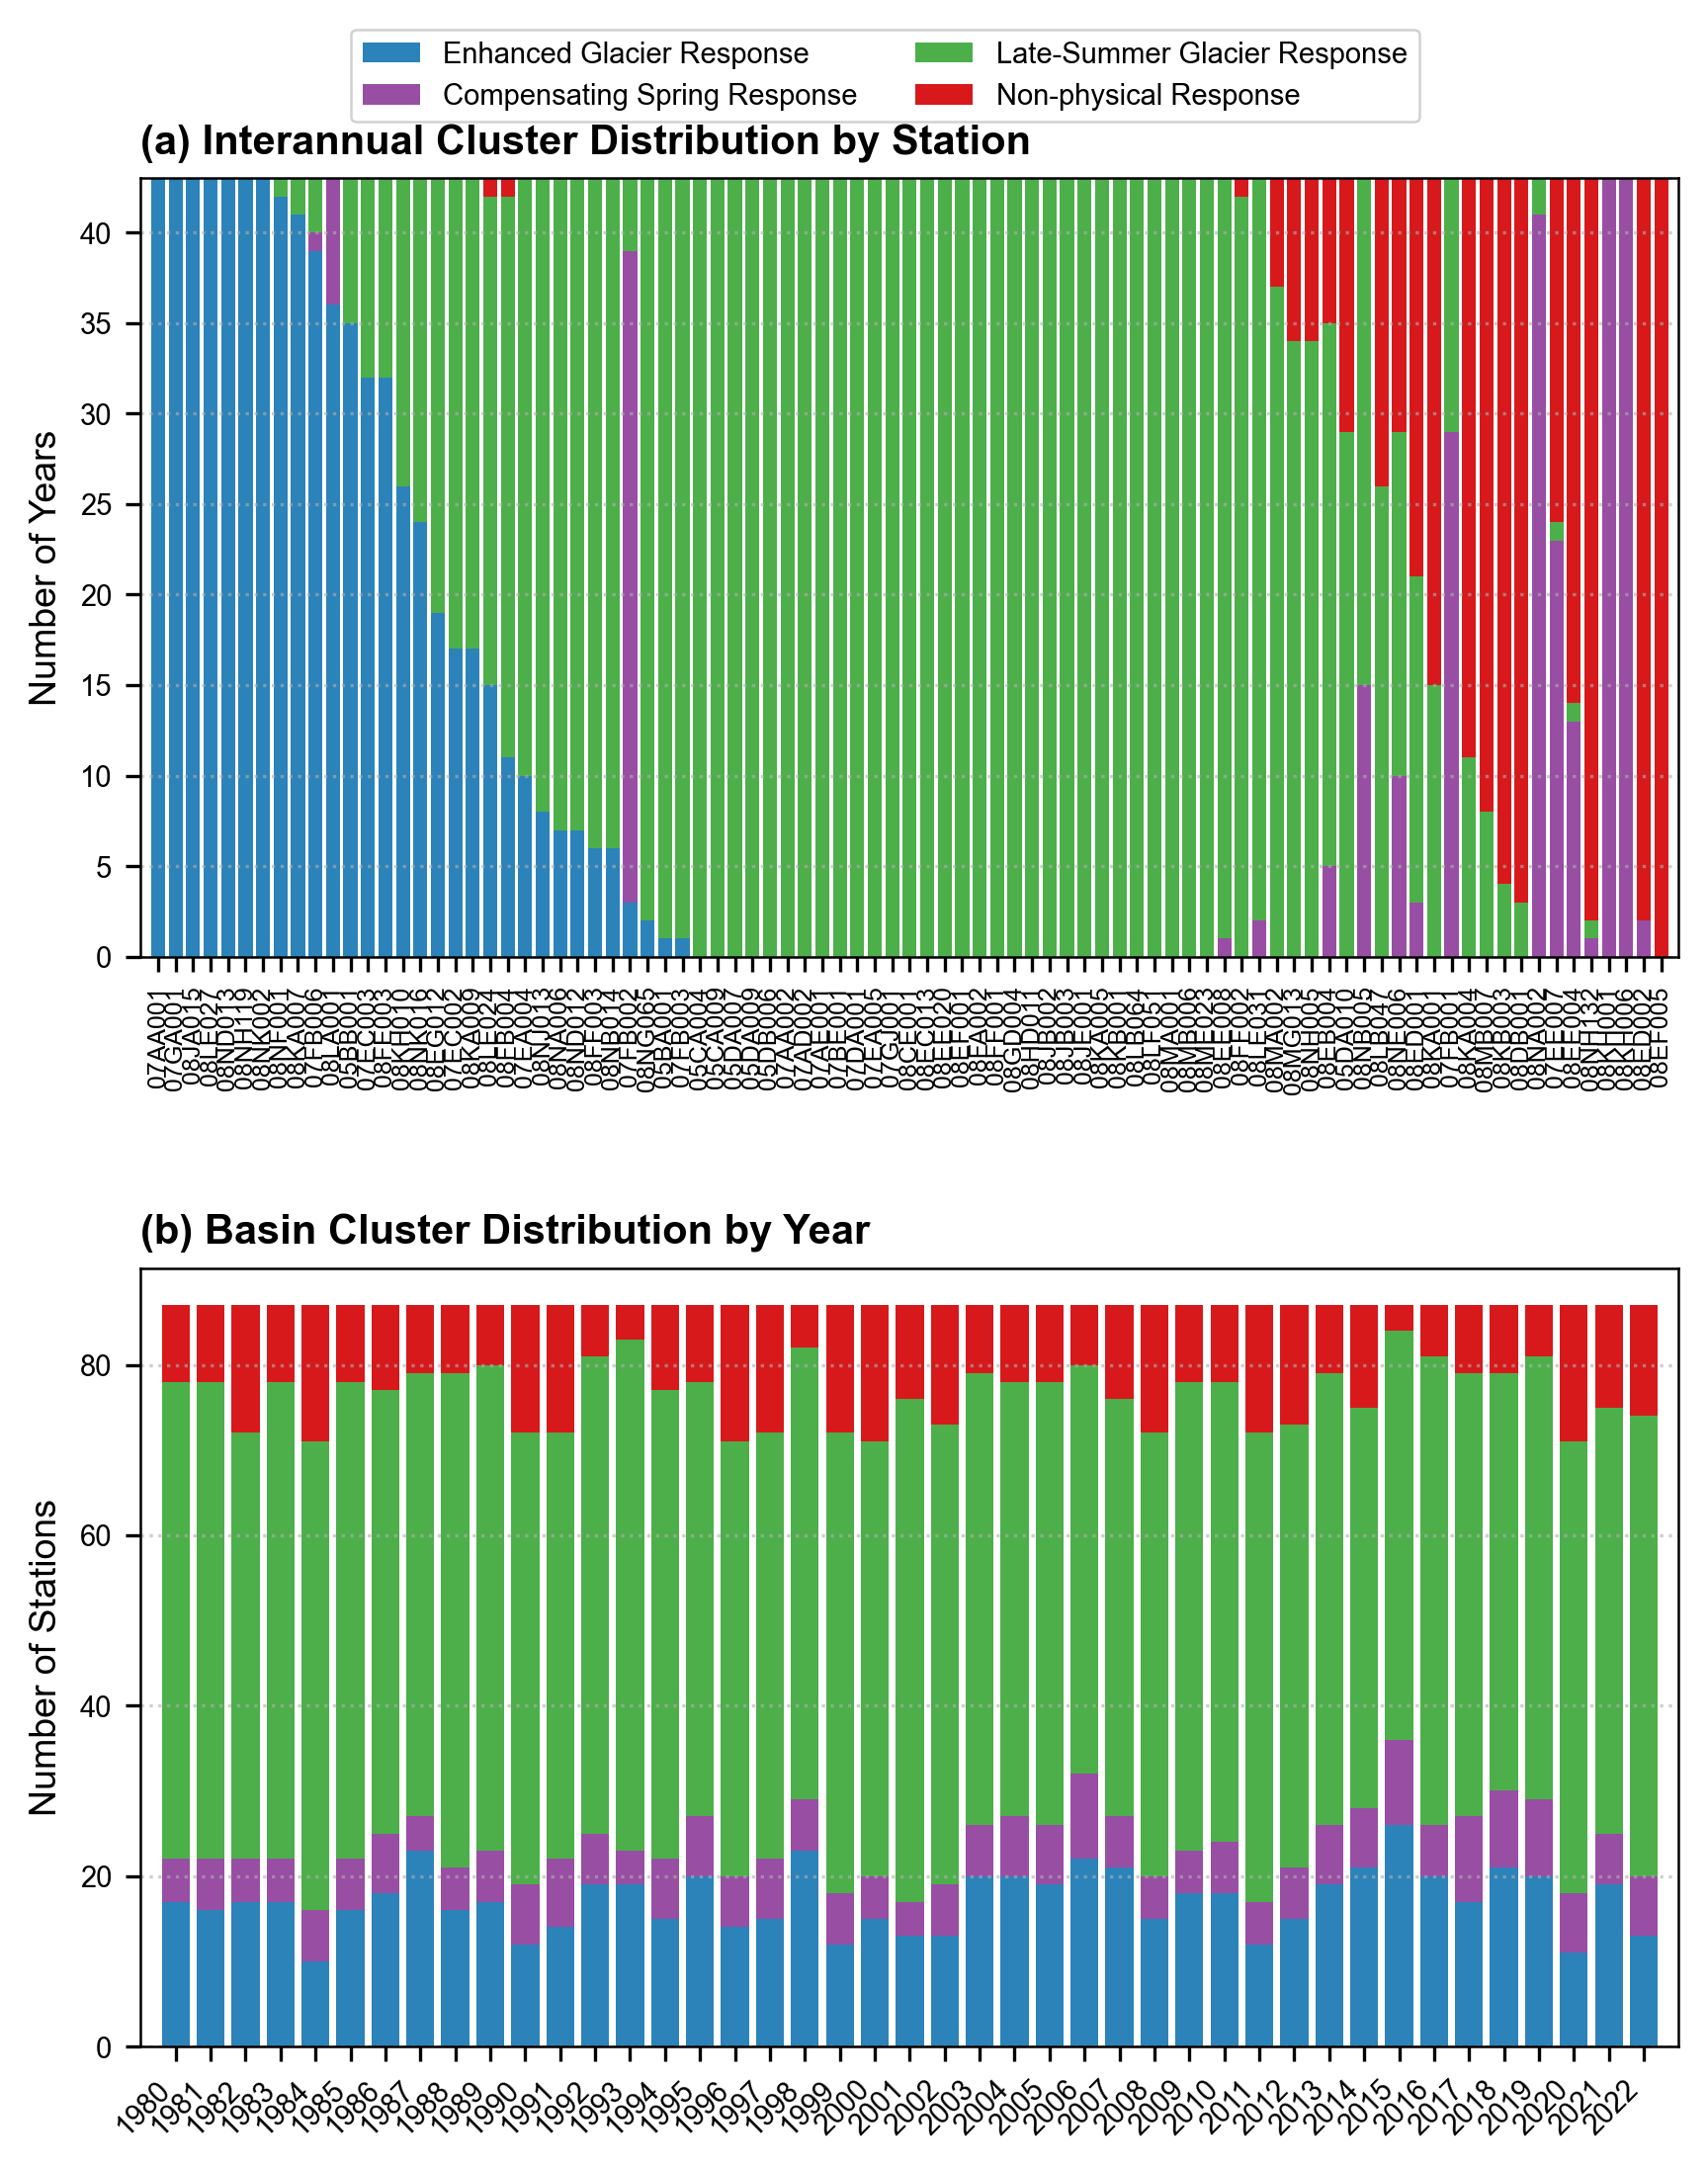

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Define standard sizing locally for the figure
cm = 1 / 2.54
MAX_PAGE_WIDTH = 17.0 * cm 

# Define cluster aesthetics
cluster_colors = {
    0: '#2b83ba',  # Blue
    1: '#984ea3',  # Purple
    2: '#4daf4a',  # Green
    3: '#d7191c'   # Red
}

cluster_names = {
    0: "Enhanced Glacier Response",
    1: "Compensating Spring Response",
    2: "Late-Summer Glacier Response",
    3: "Non-physical Response"
}

# --- 1. PREPARE THE DATA ---
# Group by Station
station_counts = df_som_clusters.groupby(['Station', 'Cluster']).size().unstack(fill_value=0)

# Sort stations by the prevalence of Cluster 0, then 2, etc., to create a smooth visual gradient
sort_cols = [c for c in [0, 2, 1, 3] if c in station_counts.columns]
if sort_cols:
    station_counts = station_counts.sort_values(by=sort_cols, ascending=False)

# Group by Year
year_counts = df_som_clusters.groupby(['Year', 'Cluster']).size().unstack(fill_value=0)

# --- 2. SETUP FIGURE ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(MAX_PAGE_WIDTH, 20 * cm), gridspec_kw={'hspace': 0.4})

# Plot (a): Distribution by Station
bottom_station = np.zeros(len(station_counts))
for c in sorted(station_counts.columns):
    ax1.bar(
        station_counts.index.astype(str), 
        station_counts[c], 
        bottom=bottom_station, 
        color=cluster_colors[c], 
        edgecolor='none', 
        label=cluster_names[c]
    )
    bottom_station += station_counts[c]

ax1.set_title('(a) Interannual Cluster Distribution by Station', loc='left', fontweight='bold')
ax1.set_ylabel('Number of Years')
ax1.set_xlim(-1, len(station_counts))
ax1.set_xticks(range(len(station_counts)))
ax1.set_xticklabels(station_counts.index, rotation=90, fontsize=6) 
ax1.grid(axis='y', linestyle=':', alpha=0.6)

# Plot (b): Distribution by Year
bottom_year = np.zeros(len(year_counts))
for c in sorted(year_counts.columns):
    ax2.bar(
        year_counts.index.astype(str), 
        year_counts[c], 
        bottom=bottom_year, 
        color=cluster_colors[c], 
        edgecolor='none'
    )
    bottom_year += year_counts[c]

ax2.set_title('(b) Basin Cluster Distribution by Year', loc='left', fontweight='bold')
ax2.set_ylabel('Number of Stations')
ax2.set_xlim(-1, len(year_counts))
ax2.set_xticks(range(len(year_counts)))
ax2.set_xticklabels(year_counts.index, rotation=45, ha='right')
ax2.grid(axis='y', linestyle=':', alpha=0.6)

# --- 3. FORMATTING ---
# Extract handles from the first axis to create a unified legend at the top
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=2, framealpha=0.9)

# Adjust top margin to accommodate the figure-level legend
plt.subplots_adjust(top=0.88, bottom=0.08)
plt.show()